# 03A — Sunspot analysis: NOAA active regions

Analysis and plots for the Löptien-comparison NOAA regions. It reads the three corrected
cubes `02A_data_procesing.ipynb` wrote into `data/processed/NOAA_<noaa>_<date>/` and does
everything else itself.

**The regions are defined in this notebook**, in `REGION_KWARGS` in the setup cell: umbra,
penumbra, hot spot and the quiet-sun mask are all rebuilt from the cubes by `build_regions`
on every run. 02A applies corrections and stops. That split exists because 02A's corrections
re-read every per-frame FITS header — ~90 s per region — and none of that work depends on
where an umbra boundary is drawn, so retuning a threshold or a tracker costs one run of
*this* notebook and never a re-run of 02A.

This notebook still computes **no corrections**: the cube values it plots are exactly what
is on disk and what DS9 shows.

It follows the same steps as the original `03T_data_analisis.ipynb` DS0X sections, driven
by the same `src/sunspot_analysis.py` functions:

| Step | What |
| --- | --- |
| 1 | Load the region and build its regions (`load_noaa_region`) |
| 2 | Region visual — continuum and magnetogram with the mask overlays |
| 3 | Per-frame metrics, including the **hot spot** |
| 4 | Time series: mean B and mean v, plus area |
| 5 | HTML animation |
| 6 | 24 h oscillation fit, and its amplitude vs the Wilson depression |

FFT and the metrics CSV are deliberately left out for now.

## What the regions mean

- **Umbra / penumbra** — continuum thresholds, each frame against its *own* quiet-sun
  intensity, so the masks don't drift with limb darkening as the region rotates. Restricted
  to **one connected sunspot**, tracked between frames, so the areas measure a spot rather
  than every dark pixel in the box (`cluster_mode` in `REGION_KWARGS`).
- **Hot spot** — the strong-field core *inside* the sunspot footprint
  (`|B| > 500 G` by default). It overlaps umbra and penumbra rather than being a
  separate region; on the mean-magnetogram panel it appears as the orange `Hot spot` line.
- **Quiet sun** — the complement of the *unrestricted* threshold footprint, per frame. It
  excludes every dark pixel, not just the selected spot, so a second sunspot in the box is
  never averaged into the quiet-sun reference that everything downstream subtracts.

## Reading the intensities

The continuum has been divided by its **limb-darkening** factor `C(mu)` (Castellanos Durán
& Kleint 2020, Eqs. 1–2), so the ~5% hump the raw frame means carry as the region rotates
in from the limb and back out is gone, as is the 3–11% gradient across each frame. Values
are still in **DN/s** — Eq. 3's DN→cgs conversion is deliberately not applied, since
everything measured here is a ratio of intensities. The absolute DN thresholds printed in
Step 1 are therefore higher than the raw frames would suggest; they are `I_qs × 0.60 / 0.90`
of the *corrected* intensity.

## Reading the velocities

The dopplergram is on an **absolute** m/s scale — the four Castellanos Durán et al. (2021)
zero-point corrections have been applied, so 0 means no line-of-sight motion rather than
"whatever the quiet sun averaged to". A residual offset of order 100–200 m/s in the quiet
sun is expected (HMI's known absolute-Doppler bias), so read the umbra *relative to the
quiet-sun line*, not relative to zero.

The magnetogram is **signed** and uncorrected for line-of-sight projection — see the
caveats in `02A`.

## Gaps

The time axis is uniform by construction and any frame a series was missing is a **NaN
frame** in the right slot. `data['present']` is derived from the cubes directly — an all-NaN
frame is unambiguous — so nothing has to stay in sync with a saved flag. Breaks in the
plotted lines are those gaps.

## Files

02A writes three cubes plus `region_01_frames.fits` (per-frame correction diagnostics:
`I_QS`, `C_MEAN`, the four Doppler terms, the magnetogram plane gradient). It writes **no
mask file** — a saved mask could only go stale against the thresholds set here. Use the
*Export the masks for DS9* cell when you want the overlay.

In [79]:
import sys
import pathlib

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import numpy as np
import matplotlib.pyplot as plt

from src.sunspot_analysis import (
    load_noaa_region,
    build_regions,
    write_masks_cube,
    compute_metrics,
    plot_calibration_frame,
    plot_magnetogram_masks,
    plot_time_series,
    plot_area,
    save_animation,
    MIN_CLUSTER_PX,
    DEFAULT_HOTSPOT_G,
)

PROCESSED_DIR = pathlib.Path('../data/processed')

# ── The regions are defined HERE ─────────────────────────────────────────────
# 02A only produces the three corrected cubes. Every region — umbra, penumbra, hot spot,
# quiet sun — is rebuilt from those cubes by `build_regions` on every run of this notebook,
# so changing anything below costs one re-run of 03A and never a re-run of 02A.
#
# Thresholds are fractions of each frame's *own* quiet-sun continuum intensity, not absolute
# DN. An absolute cut makes the mask areas drift as the region rotates, and for a near-limb
# region the whole frame can fall under a fixed penumbra cut.
#
# cluster_mode restricts umbra and penumbra to ONE connected sunspot: the combined
# umbra|penumbra footprint is labelled into connected components and one is kept, because a
# sunspot is one connected dark region with its umbra nested inside its penumbra. Without it
# the masks are every dark pixel in the box — other spots, pores, bad pixels — and NOAA
# 11117's umbra area drifted 98% across its window as a result.
#   'largest' by area     'central' nearest the box centre     None no selection at all
#
# cluster_track follows the same spot between frames by maximum overlap instead of re-picking
# by `cluster_mode` each time. Two comparable spots otherwise make the selection flip
# mid-window, putting a step into every series.
#
# cluster_min_area drops components below this many pixels before choosing. Not cosmetic:
# penumbra_frac = 0.90 sits near the 8th percentile of a quiet-sun box, so the threshold
# catches the dark tail of granulation — one NOAA 11536 frame labels into ~160 components,
# ~150 of them speckle under 50 px. Dropping them also stops the "largest" component
# percolating through the speckle field and merging spots that are not really connected.
REGION_KWARGS = dict(
    umbra_frac       = 0.60,   # I < 0.60 I_qs            -> umbra
    penumbra_frac    = 0.90,   # I < 0.90 I_qs, not umbra -> penumbra
    qsun_percentile  = 80,     # percentile of finite pixels used as the frame's I_qs
    cluster_mode     = 'largest',
    cluster_track    = True,
    cluster_min_area = MIN_CLUSTER_PX,
    hotspot_gauss    = DEFAULT_HOTSPOT_G,   # hot spot = |B| > 500 G inside the sunspot
)

# Per-AR hot-spot filter, for when |B| is not what you want. The default is on |B| rather
# than signed B on purpose: the DS notebooks used `b > 500` or `b < -500` chosen per region,
# and getting the sign wrong yields an *empty* mask rather than an error — NOAA 11536's umbra
# averages about -400 G, so `b > 500` would select nothing there. Override only to isolate
# one polarity of a bipolar group deliberately.
hotspot_override = {
    # 11536: lambda b: b < -500,   # negative polarity only
}


def region_noaa(region_dir):
    """NOAA number from a `NOAA_<number>_<date>` directory name, or None."""
    parts = region_dir.name.split('_')
    return int(parts[1]) if len(parts) > 1 and parts[1].isdigit() else None


def region_kwargs_for(region_dir):
    """REGION_KWARGS plus this AR's hot-spot override, if it has one."""
    kwargs = dict(REGION_KWARGS)
    override = hotspot_override.get(region_noaa(region_dir))

    if region_noaa(region_dir) == 11117:
        kwargs['cluster_mode'] = None

    if override is not None:
        kwargs['mag_filter'] = override
    return kwargs


regions = sorted(p for p in PROCESSED_DIR.glob('NOAA_*')
                 if (p / 'region_01_continuum_cube.fits').exists())

print(f'{len(regions)} processed region(s):')
for i, r in enumerate(regions):
    print(f'  [{i}] {r.name}')
if not regions:
    print('  none — run 02A_data_procesing.ipynb first')

4 processed region(s):
  [0] NOAA_11106_2010-09-16
  [1] NOAA_11117_2010-10-27
  [2] NOAA_11363_2011-12-06
  [3] NOAA_11536_2012-07-31


# 11106

In [2]:
REGION_INDEX = 0

region_dir   = regions[REGION_INDEX]
plots_dir    = region_dir / 'plots'

# The masks are built right here from the corrected cubes, with REGION_KWARGS from the setup
# cell. Retune anything there and re-run from this cell down — 02A does not need to run again.
data = load_noaa_region(region_dir, **region_kwargs_for(region_dir))

print(f'{region_dir.name}')
print(f"  cube shape (n_t, ny, nx) : {data['cube_cont'].shape}")
print(f"  time span                : {data['time_h'][-1]:.1f} h "
      f"({data['n_t']} frames @ {data['cadence_s']:.0f} s)")
print(f"  segmentation (abs. DN)   : umbra < {data['umbra_thresh']:,.0f}, "
      f"penumbra < {data['penumbra_thresh']:,.0f}")

# Gap frames are NaN slots on 02A's uniform grid — a series had no frame at that time. They
# are not measurements, so anything derived from them is NaN by design.
present = data['present']
n_gaps = {k: int((~v).sum()) for k, v in present.items()}
if any(n_gaps.values()):
    print(f'  NaN (missing) frames     : {n_gaps}')
    for name, flags in present.items():
        missing = np.flatnonzero(~flags)
        for i in missing[:5]:
            print(f"      {name}: frame {i} = {data['timestamps'][i]:%Y-%m-%d %H:%M}")
        if len(missing) > 5:
            print(f'      {name}: ... and {len(missing) - 5} more')
else:
    print('  NaN (missing) frames     : none')

# How the cluster selection went. `switched` is the one to watch: if the tracker lost the
# spot and re-picked, every series has a step at that frame and nothing else would show it.
# It is not automatically a bug — a decaying spot legitimately vanishes out from under the
# tracker near the end of a long window, so check *when* it happened.
info = data['cluster_info']
if info is not None:
    with_spot = info['area'] > 0
    print(f"  cluster                  : mode={data['cluster_mode']}  "
          f"{info['n_clusters'][with_spot].min()}-{info['n_clusters'][with_spot].max()} "
          f"components/frame, keeping {100 * np.nanmean(info['fraction']):.0f}% of the dark pixels")
    switched = np.flatnonzero(info['switched'])
    if len(switched):
        print(f'  WARNING: tracker re-picked the spot in {len(switched)} frame(s), first at '
              f"{data['timestamps'][switched[0]]:%Y-%m-%d %H:%M} (frame {switched[0]})")

# Areas over the frames that have data, so a gap can't drag the mean down. `raw` is the same
# count before the cluster selection — the difference is other spots, pores and bad pixels.
with_data = present['cont']
raw = data['raw_area_px']
for name, key in [('umbra', 'umbra'), ('penumbra', 'penumbra'), ('hot_spot', None)]:
    area = data[name].sum(axis=(1, 2))[with_data]
    before = f"  (raw {raw[key][with_data].mean():.0f})" if key else ''
    print(f'  {name:9s} area px        : mean={area.mean():.0f}  min={area.min()}  '
          f'max={area.max()}{before}')


NOAA_11106_2010-09-16
  cube shape (n_t, ny, nx) : (480, 648, 648)
  time span                : 95.8 h (480 frames @ 720 s)
  segmentation (abs. DN)   : umbra < 39,292, penumbra < 58,938
  NaN (missing) frames     : {'cont': 28, 'mag': 28, 'dop': 28}
      cont: frame 32 = 2010-09-16 06:36
      cont: frame 33 = 2010-09-16 06:48
      cont: frame 34 = 2010-09-16 07:00
      cont: frame 35 = 2010-09-16 07:12
      cont: frame 36 = 2010-09-16 07:24
      cont: ... and 23 more
      mag: frame 32 = 2010-09-16 06:36
      mag: frame 33 = 2010-09-16 06:48
      mag: frame 34 = 2010-09-16 07:00
      mag: frame 35 = 2010-09-16 07:12
      mag: frame 36 = 2010-09-16 07:24
      mag: ... and 23 more
      dop: frame 32 = 2010-09-16 06:36
      dop: frame 33 = 2010-09-16 06:48
      dop: frame 34 = 2010-09-16 07:00
      dop: frame 35 = 2010-09-16 07:12
      dop: frame 36 = 2010-09-16 07:24
      dop: ... and 23 more
  cluster                  : mode=largest  2-13 components/frame, keeping 38%

## Step 2 — Region visual

Check that the masks land on the spot before trusting any number derived from them.

- **Continuum** (`plot_calibration_frame`) — umbra and penumbra over the intensity image.
- **Magnetogram** (`plot_magnetogram_masks`) — purple is the whole sunspot, green is the
  hot spot. The hot spot should sit on the strong-field core, not scattered across the
  frame; if it is empty or covers everything, the `|B|` threshold in 02A needs adjusting
  for this region.

Both take `frame_idx=None` for the middle frame. Worth repeating near the start and end of
the window when the spot evolves noticeably.

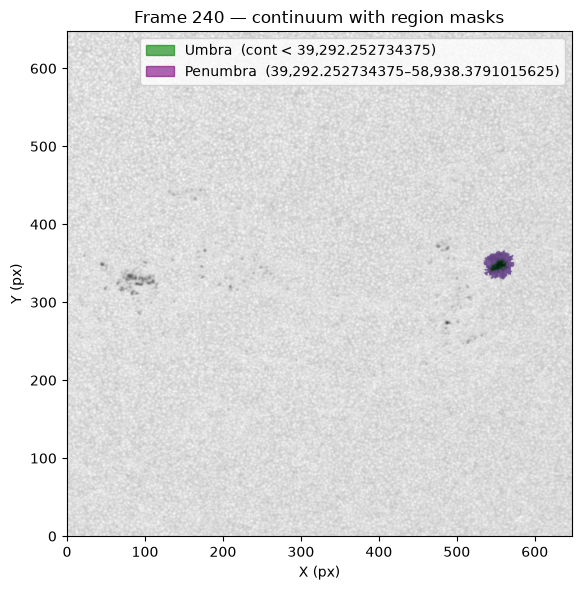

In [3]:
plot_calibration_frame(data, frame_idx=None, save=False, plots_dir=plots_dir)

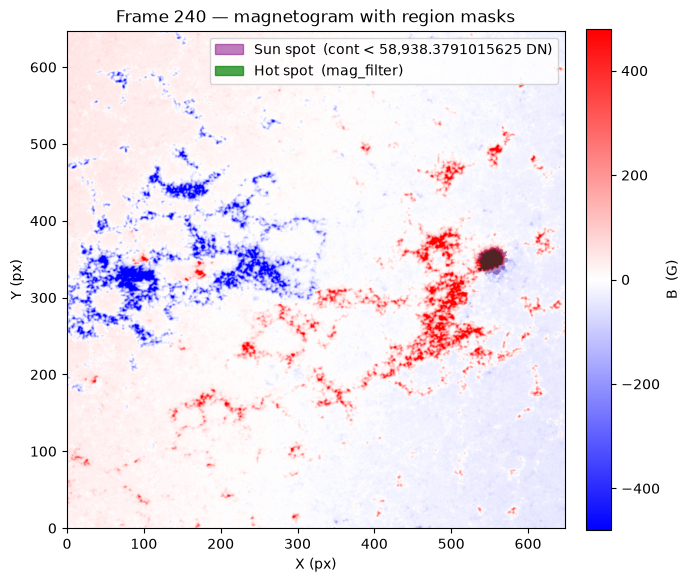

In [4]:
plot_magnetogram_masks(data, frame_idx=None, save=False, plots_dir=plots_dir)

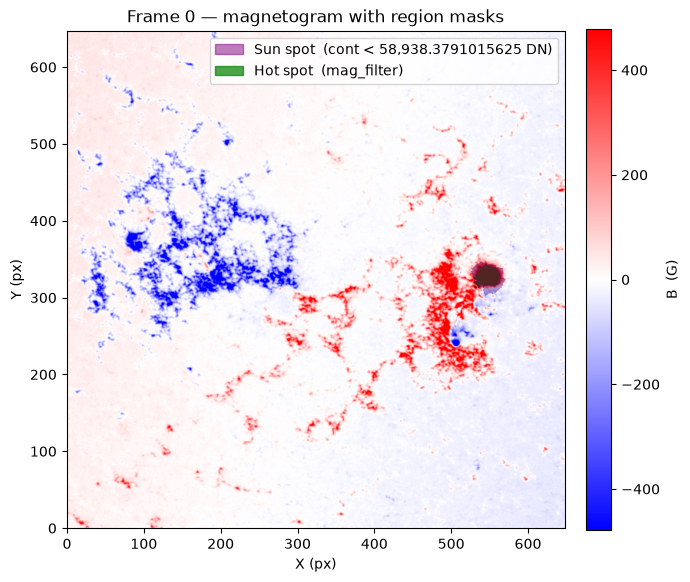

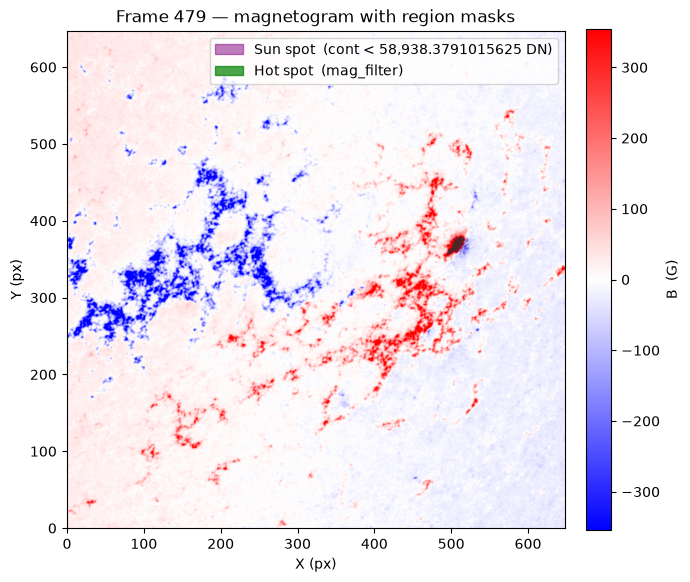

In [5]:
# First and last frame — does the mask still track the spot at the end of the window?
for idx in (0, data['n_t'] - 1):
    plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

## Step 3 — Per-frame metrics

`compute_metrics` returns the mean magnetogram and Doppler velocity per region per frame.
Because `data['hot_spot']` is present it also returns **`mean_mag_hotspot`** and
`area_hotspot` (magnetogram only — a hot spot has no separate Doppler meaning).

**Read the two B columns together.** `compute_metrics` averages *signed* `B_los`, so a
bipolar group cancels against itself: NOAA 11536's hot spot is 27% positive and 73%
negative, which drags its signed mean (−348 G) to under half its actual `|B|` (819 G).
That matters for a pulsation search, because the signed mean can move simply because the
polarity balance moved — a change in which pixels are in the mask, not a change in field
strength. The `|B|` column is there to tell those apart.

The hot-spot mean should otherwise fall between the umbral and penumbral means: it is the
strong-field core, which spans parts of both.

In [6]:
metrics = compute_metrics(data)

print(f'{region_dir.name}\n')
print('  region        mean B (G)     |B| (G)    mean v (m/s)      area (px)')
rows = [
    ('Umbra',     'mean_mag_umb',     'mean_dop_umb',   'area_umb',     'umbra'),
    ('Penumbra',  'mean_mag_pen',     'mean_dop_pen',   'area_pen',     'penumbra'),
    ('Both',      'mean_mag_both',    'mean_dop_both',  'area_both',    'both'),
    ('Hot spot',  'mean_mag_hotspot', None,             'area_hotspot', 'hot_spot'),
    ('Quiet Sun', 'mean_mag_quiet',   'mean_dop_quiet', None,           None),
]
for label, mag_key, dop_key, area_key, mask_key in rows:
    if mag_key not in metrics:
        continue
    mag   = f'{np.nanmean(metrics[mag_key]):10.1f}'
    unsig = (f'{np.nanmean(np.abs(data["cube_mag"][data[mask_key]])):11.1f}'
             if mask_key else f'{"—":>11s}')
    dop   = f'{np.nanmean(metrics[dop_key]):12.1f}' if dop_key else f'{"—":>12s}'
    area  = f'{np.nanmean(metrics[area_key]):13.0f}' if area_key else f'{"—":>13s}'
    print(f'  {label:12s} {mag} {unsig} {dop} {area}')

# Velocities are absolute, so the physically meaningful number is the umbra relative to
# the quiet sun — suppressed convection in the umbra should leave it redshifted.
rel = np.nanmean(metrics['mean_dop_umb']) - np.nanmean(metrics['mean_dop_quiet'])
print(f'\n  umbra − quiet sun : {rel:+.1f} m/s')

# Polarity balance. compute_metrics averages *signed* B, so a bipolar group cancels
# against itself and the reported mean understates the real field — for NOAA 11536 the
# hot spot is 27% positive / 73% negative, and its signed mean (-348 G) is less than half
# its |B| (819 G). Compare the two columns above before reading anything into a trend:
# a change in the mean can be the polarity balance shifting rather than the field.
for label, mask_key in [('Umbra', 'umbra'), ('Hot spot', 'hot_spot')]:
    vals = data['cube_mag'][data[mask_key]]
    vals = vals[np.isfinite(vals)]
    if not vals.size:
        continue
    frac_pos = 100 * (vals > 0).sum() / vals.size
    print(f'  {label:10s} polarity  {frac_pos:5.1f}% positive / {100 - frac_pos:5.1f}% negative'
          + ('   <- mixed, signed mean is cancelling' if 5 < frac_pos < 95 else ''))

/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:953: RuntimeWarning: Mean of empty slice
  mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t]) for t in range(n_qsun)]),
/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:957: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t]) for t in range(n_qsun)]),


NOAA_11106_2010-09-16

  region        mean B (G)     |B| (G)    mean v (m/s)      area (px)
  Umbra            1132.4      1164.2        -54.9           218
  Penumbra          429.6       471.0       -166.5           775
  Both              583.9       623.0       -141.9           992
  Hot spot          934.1       948.4            —           546
  Quiet Sun           0.0           —       -270.7             —

  umbra − quiet sun : +215.9 m/s
  Umbra      polarity  100.0% positive /   0.0% negative
  Hot spot   polarity  100.0% positive /   0.0% negative


## Step 4 — Time series

`plot_time_series` draws mean B (top) and mean v (bottom) for umbra, penumbra, both and
quiet sun, with the **hot spot** added to the magnetogram panel in orange.

`subtract_quiet=True` re-references everything to the quiet sun, which is the right view
for the velocities given the residual HMI bias. `normalized=True` min-max scales each
series, useful for comparing the *shape* of the B and v variations rather than their size.

`plot_area` is the sanity check that belongs beside them: a mean that moves while its area
also moves is a segmentation artefact, not a measurement.

**A break in a line is a download gap, not the spot disappearing.** 02A puts the three
series on a uniform time grid and NaN-fills the slots where a series has no frame, so those
frames are missing data rather than measured zeros. `compute_metrics` sets the areas to NaN
there for the same reason — an empty mask in a gap frame would otherwise plot as a
confident drop to 0 px. `data['present']` says which slots those are.

Figure saved → ../data/processed/NOAA_11106_2010-09-16/plots/time_series.png


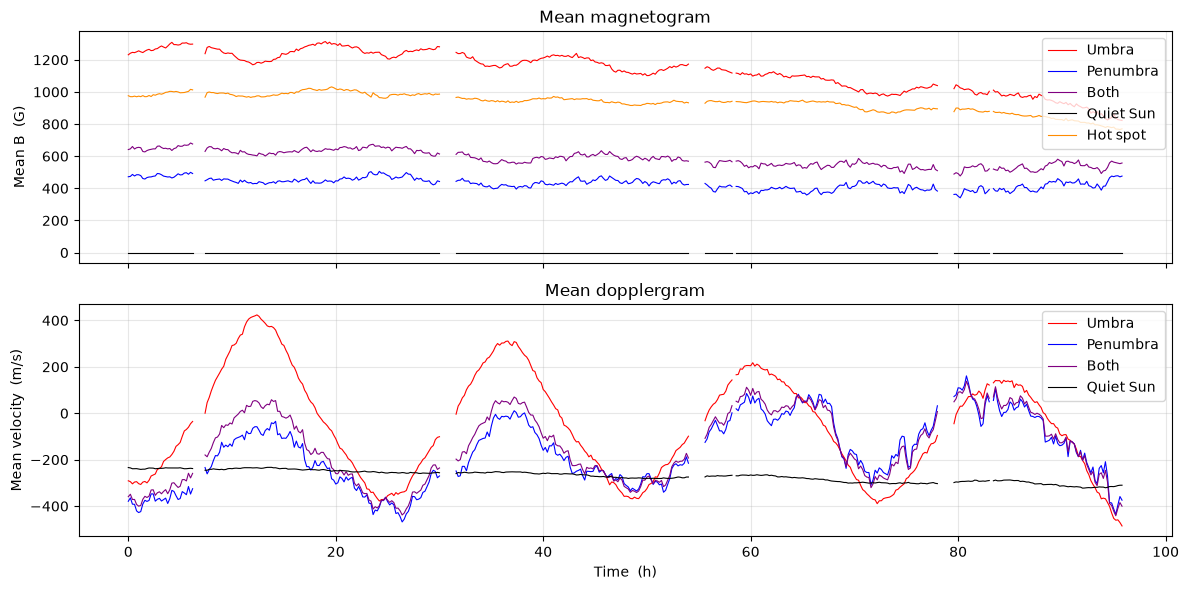

In [7]:
plot_time_series(data, metrics, save=True, plots_dir=plots_dir)

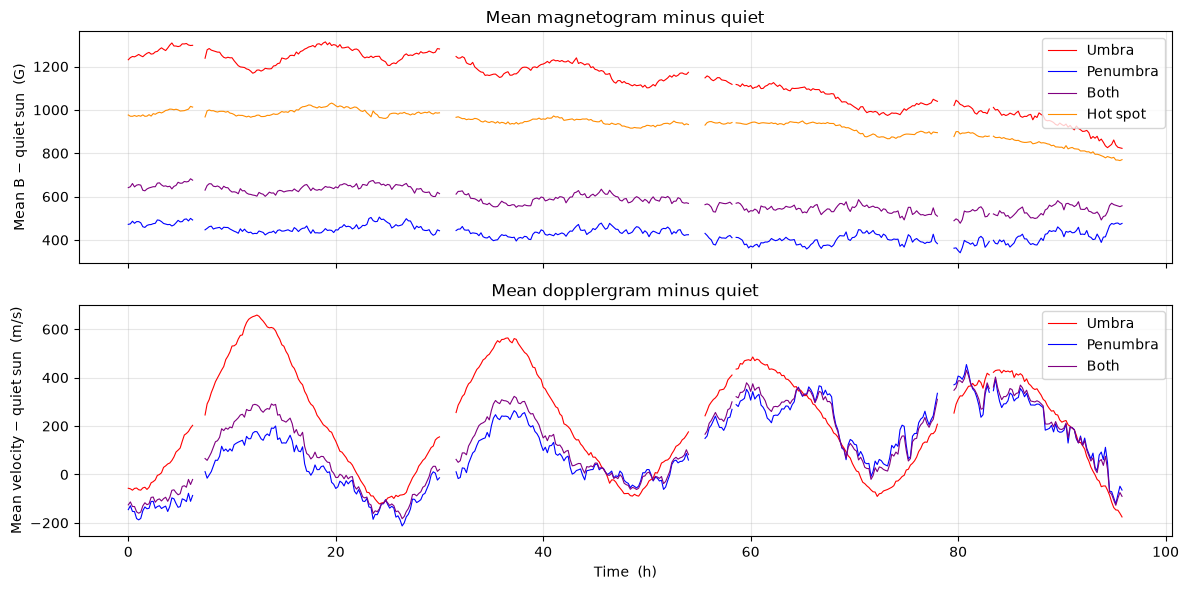

In [8]:
plot_time_series(data, metrics, subtract_quiet=True, save=False, plots_dir=plots_dir)

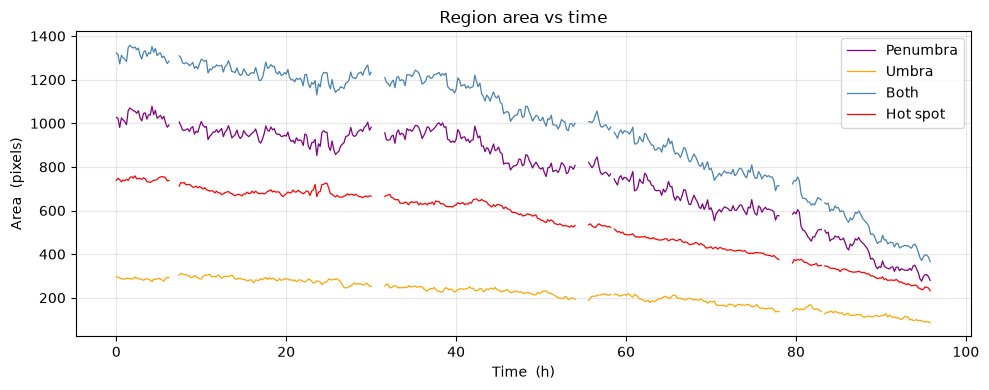

In [9]:
plot_area(data, metrics, save=False, plots_dir=plots_dir)

In [10]:
anim_path = region_dir / 'anim.html'

save_animation(
    data, metrics,
    save_path = anim_path,
    step      = max(1, data['n_t'] // 60),   # ~60 frames regardless of window length
    fps       = 5,
    mag_symmetric_cbar = True,
)

Animation size has reached 53681771 bytes, exceeding the limit of 52428800.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


Animation saved → ../data/processed/NOAA_11106_2010-09-16/anim.html  (60 frames, 53.0 MB)


In [11]:
# Open the saved animation in the browser
from IPython.display import FileLink

FileLink(str(anim_path))

/mnt/shared/Projects/sun_spots_pulsation_review/data/processed/NOAA_11106_2010-09-16/anim.html

# 11117

In [80]:
REGION_INDEX = 1

region_dir   = regions[REGION_INDEX]
plots_dir    = region_dir / 'plots'

# The masks are built right here from the corrected cubes, with REGION_KWARGS from the setup
# cell. Retune anything there and re-run from this cell down — 02A does not need to run again.
data = load_noaa_region(region_dir, **region_kwargs_for(region_dir))

print(f'{region_dir.name}')
print(f"  cube shape (n_t, ny, nx) : {data['cube_cont'].shape}")
print(f"  time span                : {data['time_h'][-1]:.1f} h "
      f"({data['n_t']} frames @ {data['cadence_s']:.0f} s)")
print(f"  segmentation (abs. DN)   : umbra < {data['umbra_thresh']:,.0f}, "
      f"penumbra < {data['penumbra_thresh']:,.0f}")

# Gap frames are NaN slots on 02A's uniform grid — a series had no frame at that time. They
# are not measurements, so anything derived from them is NaN by design.
present = data['present']
n_gaps = {k: int((~v).sum()) for k, v in present.items()}
if any(n_gaps.values()):
    print(f'  NaN (missing) frames     : {n_gaps}')
    for name, flags in present.items():
        missing = np.flatnonzero(~flags)
        for i in missing[:5]:
            print(f"      {name}: frame {i} = {data['timestamps'][i]:%Y-%m-%d %H:%M}")
        if len(missing) > 5:
            print(f'      {name}: ... and {len(missing) - 5} more')
else:
    print('  NaN (missing) frames     : none')

# How the cluster selection went. `switched` is the one to watch: if the tracker lost the
# spot and re-picked, every series has a step at that frame and nothing else would show it.
# It is not automatically a bug — a decaying spot legitimately vanishes out from under the
# tracker near the end of a long window, so check *when* it happened.
info = data['cluster_info']
if info is not None:
    with_spot = info['area'] > 0
    print(f"  cluster                  : mode={data['cluster_mode']}  "
          f"{info['n_clusters'][with_spot].min()}-{info['n_clusters'][with_spot].max()} "
          f"components/frame, keeping {100 * np.nanmean(info['fraction']):.0f}% of the dark pixels")
    switched = np.flatnonzero(info['switched'])
    if len(switched):
        print(f'  WARNING: tracker re-picked the spot in {len(switched)} frame(s), first at '
              f"{data['timestamps'][switched[0]]:%Y-%m-%d %H:%M} (frame {switched[0]})")

# Areas over the frames that have data, so a gap can't drag the mean down. `raw` is the same
# count before the cluster selection — the difference is other spots, pores and bad pixels.
with_data = present['cont']
raw = data['raw_area_px']
for name, key in [('umbra', 'umbra'), ('penumbra', 'penumbra'), ('hot_spot', None)]:
    area = data[name].sum(axis=(1, 2))[with_data]
    before = f"  (raw {raw[key][with_data].mean():.0f})" if key else ''
    print(f'  {name:9s} area px        : mean={area.mean():.0f}  min={area.min()}  '
          f'max={area.max()}{before}')


NOAA_11117_2010-10-27
  cube shape (n_t, ny, nx) : (960, 402, 402)
  time span                : 95.9 h (960 frames @ 360 s)
  segmentation (abs. DN)   : umbra < 42,012, penumbra < 63,018
  NaN (missing) frames     : {'cont': 131, 'mag': 456, 'dop': 131}
      cont: frame 390 = 2010-10-28 15:00
      cont: frame 391 = 2010-10-28 15:06
      cont: frame 393 = 2010-10-28 15:18
      cont: frame 397 = 2010-10-28 15:42
      cont: frame 398 = 2010-10-28 15:48
      cont: ... and 126 more
      mag: frame 64 = 2010-10-27 06:24
      mag: frame 66 = 2010-10-27 06:36
      mag: frame 68 = 2010-10-27 06:48
      mag: frame 70 = 2010-10-27 07:00
      mag: frame 72 = 2010-10-27 07:12
      mag: ... and 451 more
      dop: frame 390 = 2010-10-28 15:00
      dop: frame 391 = 2010-10-28 15:06
      dop: frame 393 = 2010-10-28 15:18
      dop: frame 397 = 2010-10-28 15:42
      dop: frame 398 = 2010-10-28 15:48
      dop: ... and 126 more
  umbra     area px        : mean=2369  min=826  max=3154  (r

## Step 2 — Region visual

Check that the masks land on the spot before trusting any number derived from them.

- **Continuum** (`plot_calibration_frame`) — umbra and penumbra over the intensity image.
- **Magnetogram** (`plot_magnetogram_masks`) — purple is the whole sunspot, green is the
  hot spot. The hot spot should sit on the strong-field core, not scattered across the
  frame; if it is empty or covers everything, the `|B|` threshold in 02A needs adjusting
  for this region.

Both take `frame_idx=None` for the middle frame. Worth repeating near the start and end of
the window when the spot evolves noticeably.

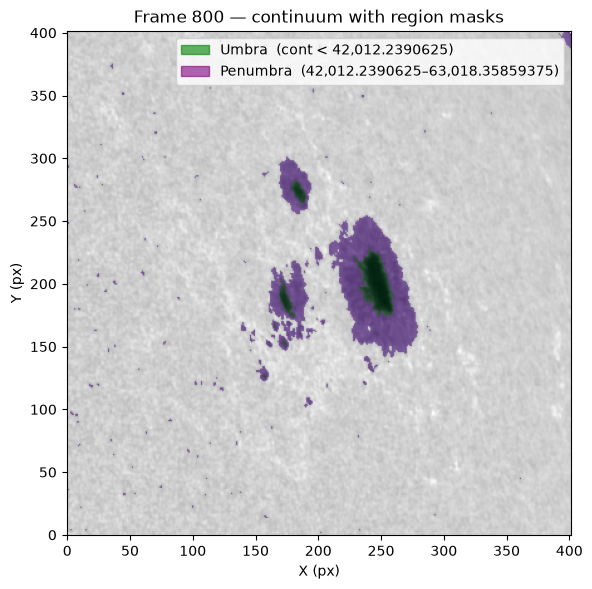

In [81]:
plot_calibration_frame(data, frame_idx=800, save=False, plots_dir=plots_dir)

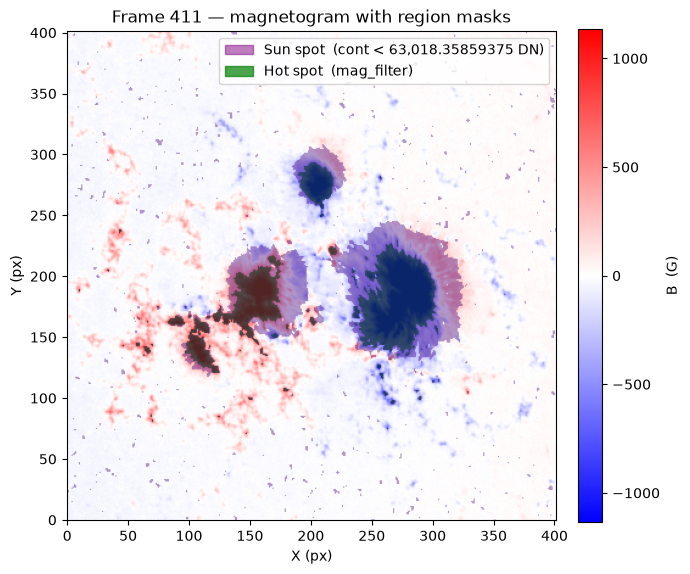

In [82]:
plot_magnetogram_masks(data, frame_idx=411, save=False, plots_dir=plots_dir)

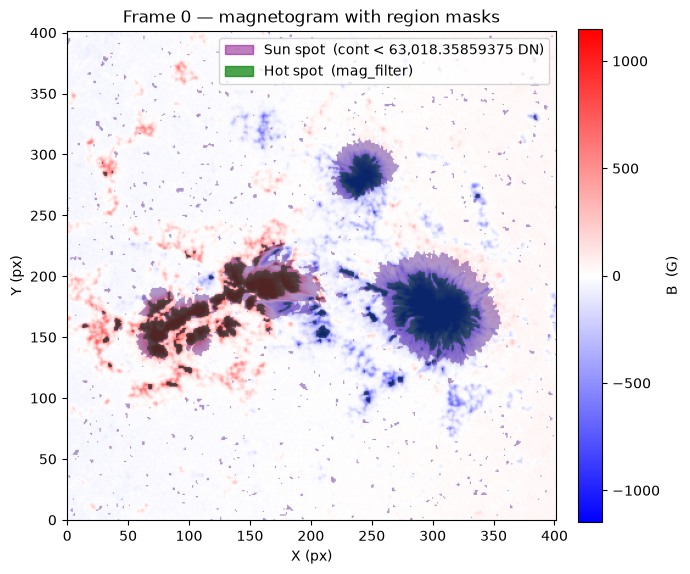

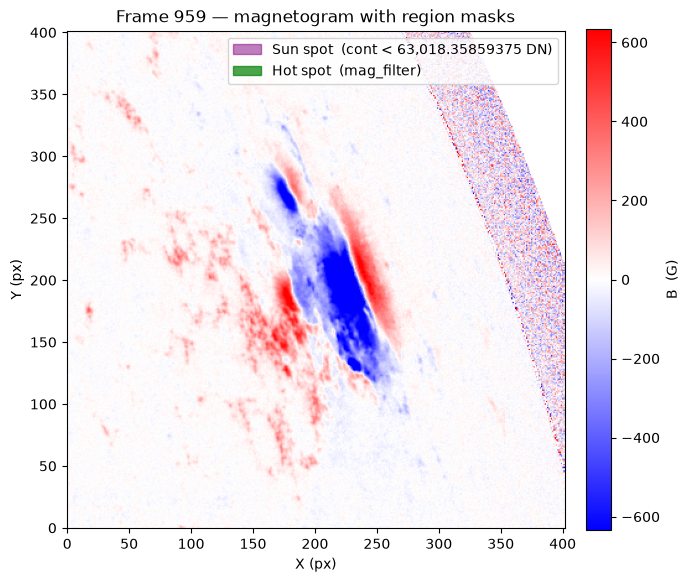

In [83]:
# First and last frame — does the mask still track the spot at the end of the window?
for idx in (0, data['n_t'] - 1):
    plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

## Step 3 — Per-frame metrics

`compute_metrics` returns the mean magnetogram and Doppler velocity per region per frame.
Because `data['hot_spot']` is present it also returns **`mean_mag_hotspot`** and
`area_hotspot` (magnetogram only — a hot spot has no separate Doppler meaning).

**Read the two B columns together.** `compute_metrics` averages *signed* `B_los`, so a
bipolar group cancels against itself: NOAA 11536's hot spot is 27% positive and 73%
negative, which drags its signed mean (−348 G) to under half its actual `|B|` (819 G).
That matters for a pulsation search, because the signed mean can move simply because the
polarity balance moved — a change in which pixels are in the mask, not a change in field
strength. The `|B|` column is there to tell those apart.

The hot-spot mean should otherwise fall between the umbral and penumbral means: it is the
strong-field core, which spans parts of both.

In [ ]:
metrics = compute_metrics(data)

print(f'{region_dir.name}\n')
print('  region        mean B (G)     |B| (G)    mean v (m/s)      area (px)')
rows = [
    ('Umbra',     'mean_mag_umb',     'mean_dop_umb',   'area_umb',     'umbra'),
    ('Penumbra',  'mean_mag_pen',     'mean_dop_pen',   'area_pen',     'penumbra'),
    ('Both',      'mean_mag_both',    'mean_dop_both',  'area_both',    'both'),
    ('Hot spot',  'mean_mag_hotspot', None,             'area_hotspot', 'hot_spot'),
    ('Quiet Sun', 'mean_mag_quiet',   'mean_dop_quiet', None,           None),
]
for label, mag_key, dop_key, area_key, mask_key in rows:
    if mag_key not in metrics:
        continue
    mag   = f'{np.nanmean(metrics[mag_key]):10.1f}'
    unsig = (f'{np.nanmean(np.abs(data["cube_mag"][data[mask_key]])):11.1f}'
             if mask_key else f'{"—":>11s}')
    dop   = f'{np.nanmean(metrics[dop_key]):12.1f}' if dop_key else f'{"—":>12s}'
    area  = f'{np.nanmean(metrics[area_key]):13.0f}' if area_key else f'{"—":>13s}'
    print(f'  {label:12s} {mag} {unsig} {dop} {area}')

# Velocities are absolute, so the physically meaningful number is the umbra relative to
# the quiet sun — suppressed convection in the umbra should leave it redshifted.
rel = np.nanmean(metrics['mean_dop_umb']) - np.nanmean(metrics['mean_dop_quiet'])
print(f'\n  umbra − quiet sun : {rel:+.1f} m/s')

# Polarity balance. compute_metrics averages *signed* B, so a bipolar group cancels
# against itself and the reported mean understates the real field — for NOAA 11536 the
# hot spot is 27% positive / 73% negative, and its signed mean (-348 G) is less than half
# its |B| (819 G). Compare the two columns above before reading anything into a trend:
# a change in the mean can be the polarity balance shifting rather than the field.
for label, mask_key in [('Umbra', 'umbra'), ('Hot spot', 'hot_spot')]:
    vals = data['cube_mag'][data[mask_key]]
    vals = vals[np.isfinite(vals)]
    if not vals.size:
        continue
    frac_pos = 100 * (vals > 0).sum() / vals.size
    print(f'  {label:10s} polarity  {frac_pos:5.1f}% positive / {100 - frac_pos:5.1f}% negative'
          + ('   <- mixed, signed mean is cancelling' if 5 < frac_pos < 95 else ''))

/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:953: RuntimeWarning: Mean of empty slice
  mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t]) for t in range(n_qsun)]),
/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:957: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t]) for t in range(n_qsun)]),


NOAA_11117_2010-10-27

  region        mean B (G)     |B| (G)    mean v (m/s)      area (px)
  Umbra            -487.6      1087.8       -240.6          2369
  Penumbra          -75.0       391.4       -219.4         11705
  Both             -145.1       509.2       -222.7         14074
  Hot spot         -301.8       898.8            —          3128
  Quiet Sun           0.0           —       -313.8             —

  umbra − quiet sun : +73.2 m/s
  Umbra      polarity   30.4% positive /  69.6% negative   <- mixed, signed mean is cancelling
  Hot spot   polarity   36.6% positive /  63.4% negative   <- mixed, signed mean is cancelling


## Step 4 — Time series

`plot_time_series` draws mean B (top) and mean v (bottom) for umbra, penumbra, both and
quiet sun, with the **hot spot** added to the magnetogram panel in orange.

`subtract_quiet=True` re-references everything to the quiet sun, which is the right view
for the velocities given the residual HMI bias. `normalized=True` min-max scales each
series, useful for comparing the *shape* of the B and v variations rather than their size.

`plot_area` is the sanity check that belongs beside them: a mean that moves while its area
also moves is a segmentation artefact, not a measurement.

**A break in a line is a download gap, not the spot disappearing.** 02A puts the three
series on a uniform time grid and NaN-fills the slots where a series has no frame, so those
frames are missing data rather than measured zeros. `compute_metrics` sets the areas to NaN
there for the same reason — an empty mask in a gap frame would otherwise plot as a
confident drop to 0 px. `data['present']` says which slots those are.

In [ ]:
metrics['mean_mag_pen']

array([ -51.605927,  -53.793446,  -48.825706,  -52.33974 ,  -52.332985,
        -54.837475,  -57.269127,  -56.781578,  -55.89533 ,  -60.53675 ,
        -61.45171 ,  -58.289093,  -62.231197,  -58.87991 ,  -58.65322 ,
        -53.661114,  -54.346348,  -57.134045,  -56.091736,  -56.17732 ,
        -54.254005,  -56.18832 ,  -55.176617,  -54.08229 ,  -52.91267 ,
        -55.613647,  -57.984947,  -63.079254,  -61.66653 ,  -61.277122,
        -58.358574,  -51.7845  ,  -51.964542,  -53.800804,  -55.522457,
        -51.77119 ,  -56.02157 ,  -58.179462,  -59.26166 ,  -61.636353,
        -54.915318,  -55.23933 ,  -59.158146,  -58.642612,  -58.694736,
        -54.91521 ,  -55.270306,  -57.866776,  -59.926838,  -61.907158,
        -61.408695,  -60.931698,  -61.87291 ,  -62.681828,  -66.060684,
        -65.417625,  -65.23794 ,  -64.46129 ,  -65.94624 ,  -60.642094,
        -60.774437,  -58.458626,  -55.550304,  -56.015106,         nan,
        -58.034866,         nan,  -58.153866,         nan,  -55.

Figure saved → ../data/processed/NOAA_11117_2010-10-27/plots/time_series.png


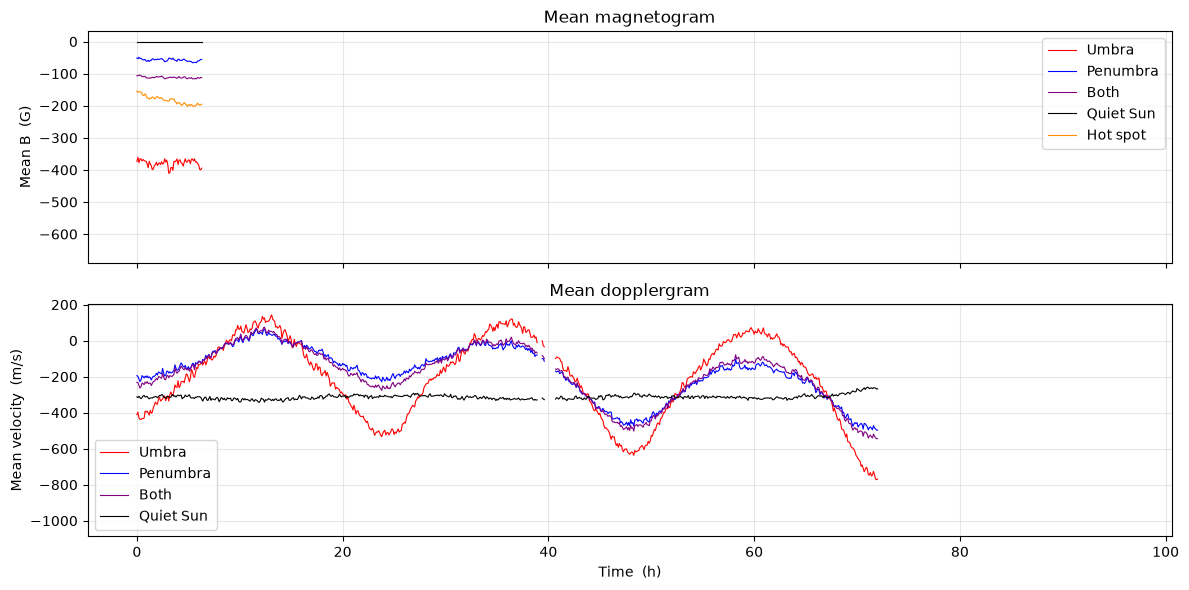

In [64]:
plot_time_series(data, metrics, save=True, plots_dir=plots_dir)

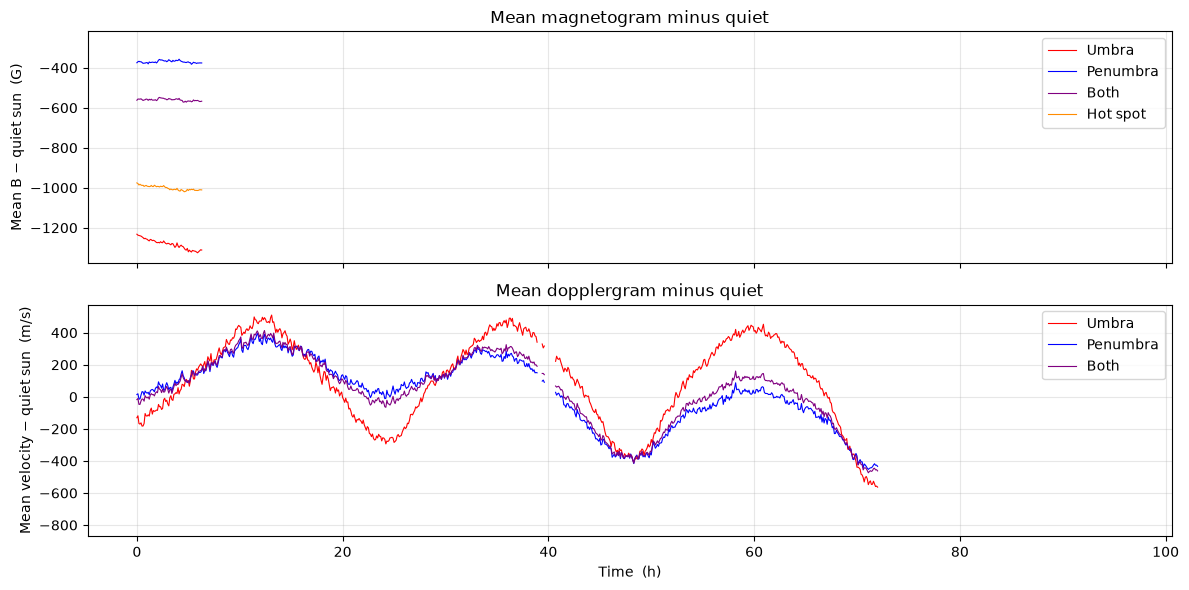

In [65]:
plot_time_series(data, metrics, subtract_quiet=True, save=False, plots_dir=plots_dir)

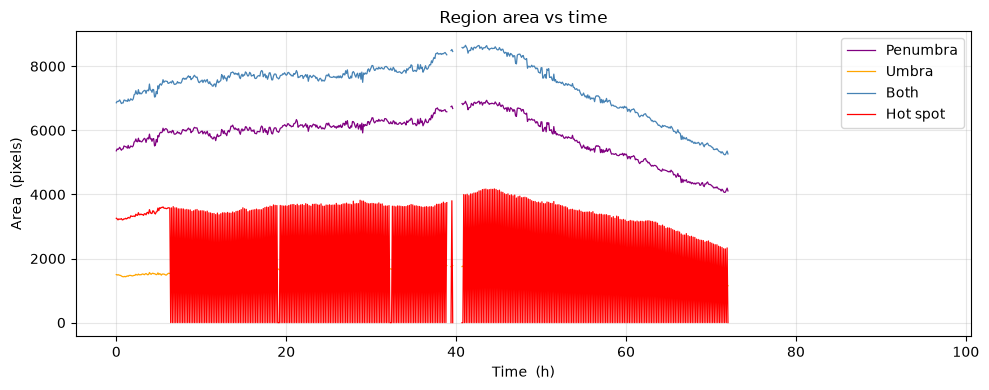

In [66]:
plot_area(data, metrics, save=False, plots_dir=plots_dir)

In [67]:
anim_path = region_dir / 'anim.html'

save_animation(
    data, metrics,
    save_path = anim_path,
    step      = max(1, data['n_t'] // 60),   # ~60 frames regardless of window length
    fps       = 5,
    mag_symmetric_cbar = True,
)

Animation size has reached 52828802 bytes, exceeding the limit of 52428800.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


Animation saved → ../data/processed/NOAA_11117_2010-10-27/anim.html  (60 frames, 52.6 MB)


In [68]:
# Open the saved animation in the browser
from IPython.display import FileLink

FileLink(str(anim_path))

/mnt/shared/Projects/sun_spots_pulsation_review/data/processed/NOAA_11117_2010-10-27/anim.html

# 11363

In [22]:
REGION_INDEX = 2

region_dir   = regions[REGION_INDEX]
plots_dir    = region_dir / 'plots'

# The masks are built right here from the corrected cubes, with REGION_KWARGS from the setup
# cell. Retune anything there and re-run from this cell down — 02A does not need to run again.
data = load_noaa_region(region_dir, **region_kwargs_for(region_dir))

print(f'{region_dir.name}')
print(f"  cube shape (n_t, ny, nx) : {data['cube_cont'].shape}")
print(f"  time span                : {data['time_h'][-1]:.1f} h "
      f"({data['n_t']} frames @ {data['cadence_s']:.0f} s)")
print(f"  segmentation (abs. DN)   : umbra < {data['umbra_thresh']:,.0f}, "
      f"penumbra < {data['penumbra_thresh']:,.0f}")

# Gap frames are NaN slots on 02A's uniform grid — a series had no frame at that time. They
# are not measurements, so anything derived from them is NaN by design.
present = data['present']
n_gaps = {k: int((~v).sum()) for k, v in present.items()}
if any(n_gaps.values()):
    print(f'  NaN (missing) frames     : {n_gaps}')
    for name, flags in present.items():
        missing = np.flatnonzero(~flags)
        for i in missing[:5]:
            print(f"      {name}: frame {i} = {data['timestamps'][i]:%Y-%m-%d %H:%M}")
        if len(missing) > 5:
            print(f'      {name}: ... and {len(missing) - 5} more')
else:
    print('  NaN (missing) frames     : none')

# How the cluster selection went. `switched` is the one to watch: if the tracker lost the
# spot and re-picked, every series has a step at that frame and nothing else would show it.
# It is not automatically a bug — a decaying spot legitimately vanishes out from under the
# tracker near the end of a long window, so check *when* it happened.
info = data['cluster_info']
if info is not None:
    with_spot = info['area'] > 0
    print(f"  cluster                  : mode={data['cluster_mode']}  "
          f"{info['n_clusters'][with_spot].min()}-{info['n_clusters'][with_spot].max()} "
          f"components/frame, keeping {100 * np.nanmean(info['fraction']):.0f}% of the dark pixels")
    switched = np.flatnonzero(info['switched'])
    if len(switched):
        print(f'  WARNING: tracker re-picked the spot in {len(switched)} frame(s), first at '
              f"{data['timestamps'][switched[0]]:%Y-%m-%d %H:%M} (frame {switched[0]})")

# Areas over the frames that have data, so a gap can't drag the mean down. `raw` is the same
# count before the cluster selection — the difference is other spots, pores and bad pixels.
with_data = present['cont']
raw = data['raw_area_px']
for name, key in [('umbra', 'umbra'), ('penumbra', 'penumbra'), ('hot_spot', None)]:
    area = data[name].sum(axis=(1, 2))[with_data]
    before = f"  (raw {raw[key][with_data].mean():.0f})" if key else ''
    print(f'  {name:9s} area px        : mean={area.mean():.0f}  min={area.min()}  '
          f'max={area.max()}{before}')


NOAA_11363_2011-12-06
  cube shape (n_t, ny, nx) : (481, 438, 438)
  time span                : 96.0 h (481 frames @ 720 s)
  segmentation (abs. DN)   : umbra < 36,799, penumbra < 55,198
  NaN (missing) frames     : {'cont': 2, 'mag': 4, 'dop': 2}
      cont: frame 211 = 2011-12-07 18:12
      cont: frame 212 = 2011-12-07 18:24
      mag: frame 104 = 2011-12-06 20:48
      mag: frame 211 = 2011-12-07 18:12
      mag: frame 212 = 2011-12-07 18:24
      mag: frame 439 = 2011-12-09 15:48
      dop: frame 211 = 2011-12-07 18:12
      dop: frame 212 = 2011-12-07 18:24
  cluster                  : mode=largest  2-16 components/frame, keeping 76% of the dark pixels
  umbra     area px        : mean=1305  min=663  max=1768  (raw 1569)
  penumbra  area px        : mean=5352  min=3629  max=6862  (raw 7426)
  hot_spot  area px        : mean=3360  min=0  max=4377


## Step 2 — Region visual

Check that the masks land on the spot before trusting any number derived from them.

- **Continuum** (`plot_calibration_frame`) — umbra and penumbra over the intensity image.
- **Magnetogram** (`plot_magnetogram_masks`) — purple is the whole sunspot, green is the
  hot spot. The hot spot should sit on the strong-field core, not scattered across the
  frame; if it is empty or covers everything, the `|B|` threshold in 02A needs adjusting
  for this region.

Both take `frame_idx=None` for the middle frame. Worth repeating near the start and end of
the window when the spot evolves noticeably.

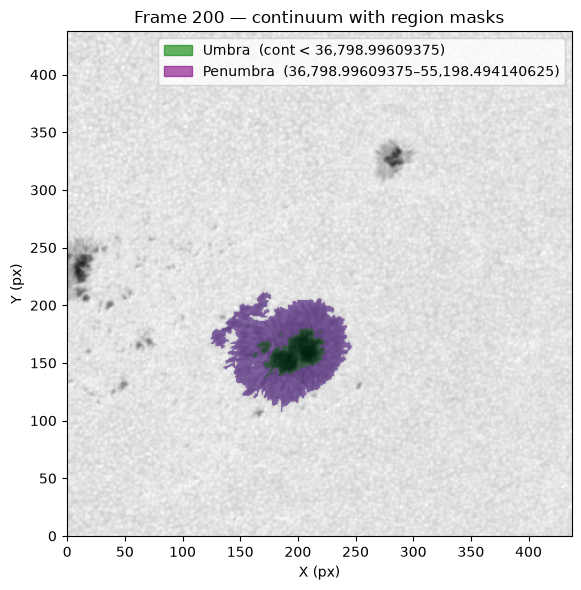

In [23]:
plot_calibration_frame(data, frame_idx=200, save=False, plots_dir=plots_dir)

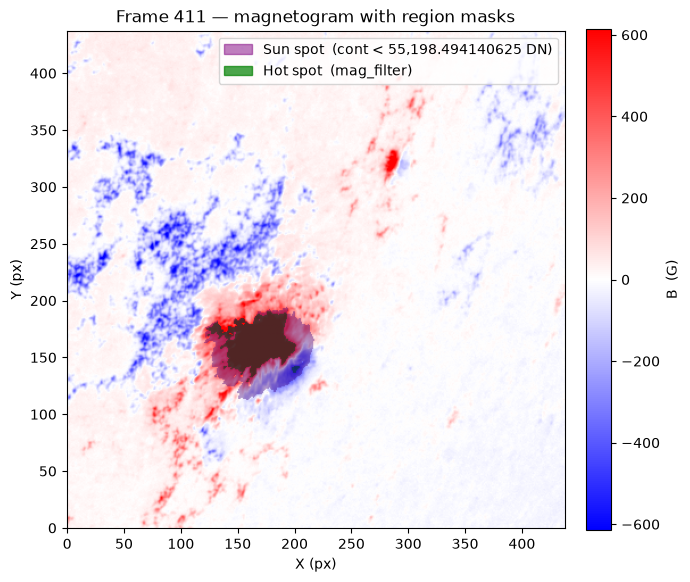

In [24]:
plot_magnetogram_masks(data, frame_idx=411, save=False, plots_dir=plots_dir)

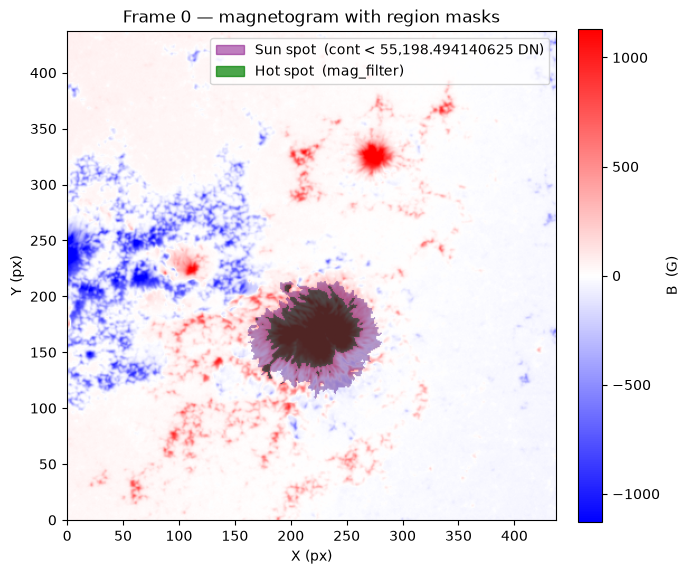

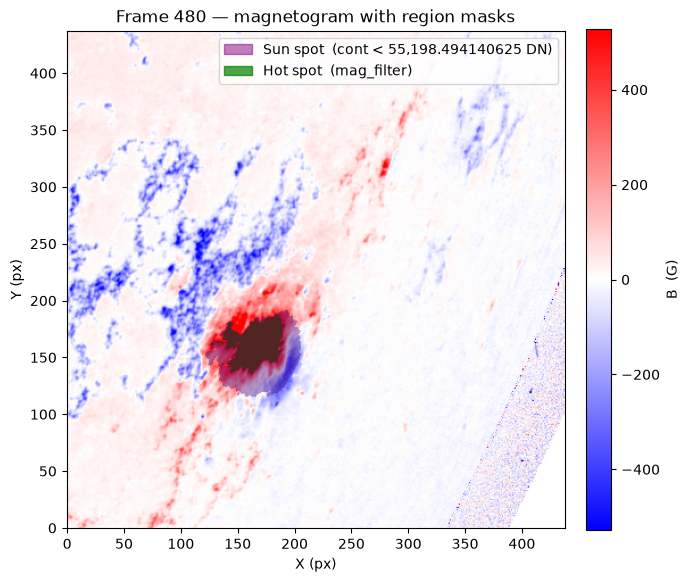

In [25]:
# First and last frame — does the mask still track the spot at the end of the window?
for idx in (0, data['n_t'] - 1):
    plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

## Step 3 — Per-frame metrics

`compute_metrics` returns the mean magnetogram and Doppler velocity per region per frame.
Because `data['hot_spot']` is present it also returns **`mean_mag_hotspot`** and
`area_hotspot` (magnetogram only — a hot spot has no separate Doppler meaning).

**Read the two B columns together.** `compute_metrics` averages *signed* `B_los`, so a
bipolar group cancels against itself: NOAA 11536's hot spot is 27% positive and 73%
negative, which drags its signed mean (−348 G) to under half its actual `|B|` (819 G).
That matters for a pulsation search, because the signed mean can move simply because the
polarity balance moved — a change in which pixels are in the mask, not a change in field
strength. The `|B|` column is there to tell those apart.

The hot-spot mean should otherwise fall between the umbral and penumbral means: it is the
strong-field core, which spans parts of both.

In [26]:
metrics = compute_metrics(data)

print(f'{region_dir.name}\n')
print('  region        mean B (G)     |B| (G)    mean v (m/s)      area (px)')
rows = [
    ('Umbra',     'mean_mag_umb',     'mean_dop_umb',   'area_umb',     'umbra'),
    ('Penumbra',  'mean_mag_pen',     'mean_dop_pen',   'area_pen',     'penumbra'),
    ('Both',      'mean_mag_both',    'mean_dop_both',  'area_both',    'both'),
    ('Hot spot',  'mean_mag_hotspot', None,             'area_hotspot', 'hot_spot'),
    ('Quiet Sun', 'mean_mag_quiet',   'mean_dop_quiet', None,           None),
]
for label, mag_key, dop_key, area_key, mask_key in rows:
    if mag_key not in metrics:
        continue
    mag   = f'{np.nanmean(metrics[mag_key]):10.1f}'
    unsig = (f'{np.nanmean(np.abs(data["cube_mag"][data[mask_key]])):11.1f}'
             if mask_key else f'{"—":>11s}')
    dop   = f'{np.nanmean(metrics[dop_key]):12.1f}' if dop_key else f'{"—":>12s}'
    area  = f'{np.nanmean(metrics[area_key]):13.0f}' if area_key else f'{"—":>13s}'
    print(f'  {label:12s} {mag} {unsig} {dop} {area}')

# Velocities are absolute, so the physically meaningful number is the umbra relative to
# the quiet sun — suppressed convection in the umbra should leave it redshifted.
rel = np.nanmean(metrics['mean_dop_umb']) - np.nanmean(metrics['mean_dop_quiet'])
print(f'\n  umbra − quiet sun : {rel:+.1f} m/s')

# Polarity balance. compute_metrics averages *signed* B, so a bipolar group cancels
# against itself and the reported mean understates the real field — for NOAA 11536 the
# hot spot is 27% positive / 73% negative, and its signed mean (-348 G) is less than half
# its |B| (819 G). Compare the two columns above before reading anything into a trend:
# a change in the mean can be the polarity balance shifting rather than the field.
for label, mask_key in [('Umbra', 'umbra'), ('Hot spot', 'hot_spot')]:
    vals = data['cube_mag'][data[mask_key]]
    vals = vals[np.isfinite(vals)]
    if not vals.size:
        continue
    frac_pos = 100 * (vals > 0).sum() / vals.size
    print(f'  {label:10s} polarity  {frac_pos:5.1f}% positive / {100 - frac_pos:5.1f}% negative'
          + ('   <- mixed, signed mean is cancelling' if 5 < frac_pos < 95 else ''))

/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:953: RuntimeWarning: Mean of empty slice
  mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t]) for t in range(n_qsun)]),
/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:957: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t]) for t in range(n_qsun)]),


NOAA_11363_2011-12-06

  region        mean B (G)     |B| (G)    mean v (m/s)      area (px)
  Umbra            1108.3      1143.5       -174.7          1305
  Penumbra          387.4       449.9       -382.6          5352
  Both              528.8       585.9       -343.4          6657
  Hot spot          910.1       926.6            —          3360
  Quiet Sun           0.0           —       -320.3             —

  umbra − quiet sun : +145.6 m/s
  Umbra      polarity   99.9% positive /   0.1% negative
  Hot spot   polarity   99.9% positive /   0.1% negative


## Step 4 — Time series

`plot_time_series` draws mean B (top) and mean v (bottom) for umbra, penumbra, both and
quiet sun, with the **hot spot** added to the magnetogram panel in orange.

`subtract_quiet=True` re-references everything to the quiet sun, which is the right view
for the velocities given the residual HMI bias. `normalized=True` min-max scales each
series, useful for comparing the *shape* of the B and v variations rather than their size.

`plot_area` is the sanity check that belongs beside them: a mean that moves while its area
also moves is a segmentation artefact, not a measurement.

**A break in a line is a download gap, not the spot disappearing.** 02A puts the three
series on a uniform time grid and NaN-fills the slots where a series has no frame, so those
frames are missing data rather than measured zeros. `compute_metrics` sets the areas to NaN
there for the same reason — an empty mask in a gap frame would otherwise plot as a
confident drop to 0 px. `data['present']` says which slots those are.

Figure saved → ../data/processed/NOAA_11363_2011-12-06/plots/time_series.png


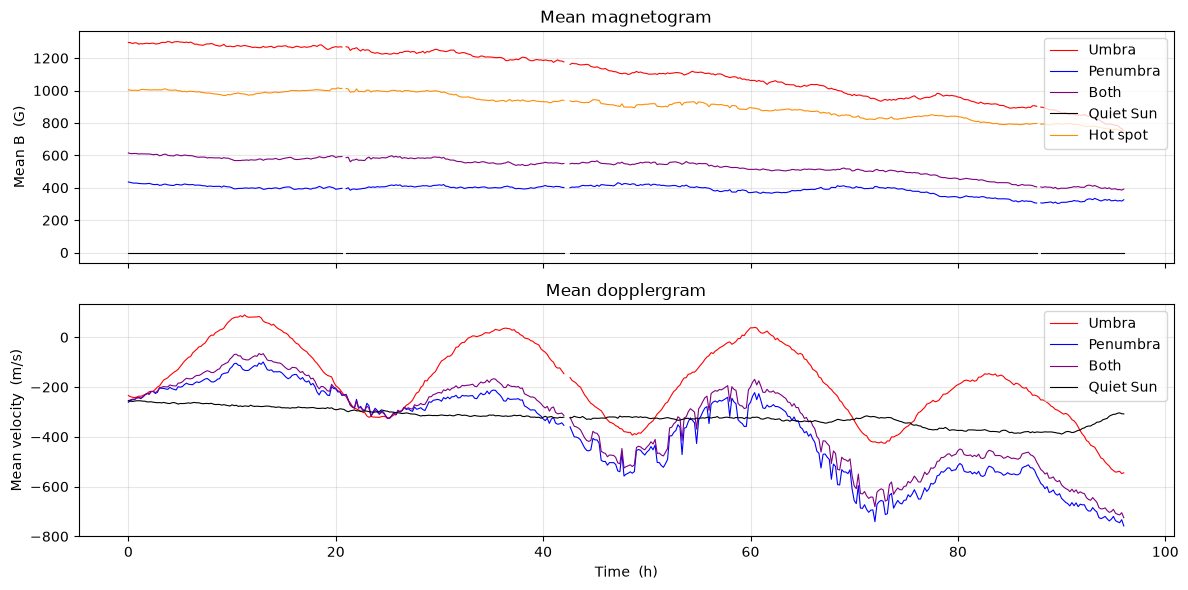

In [27]:
plot_time_series(data, metrics, save=True, plots_dir=plots_dir)

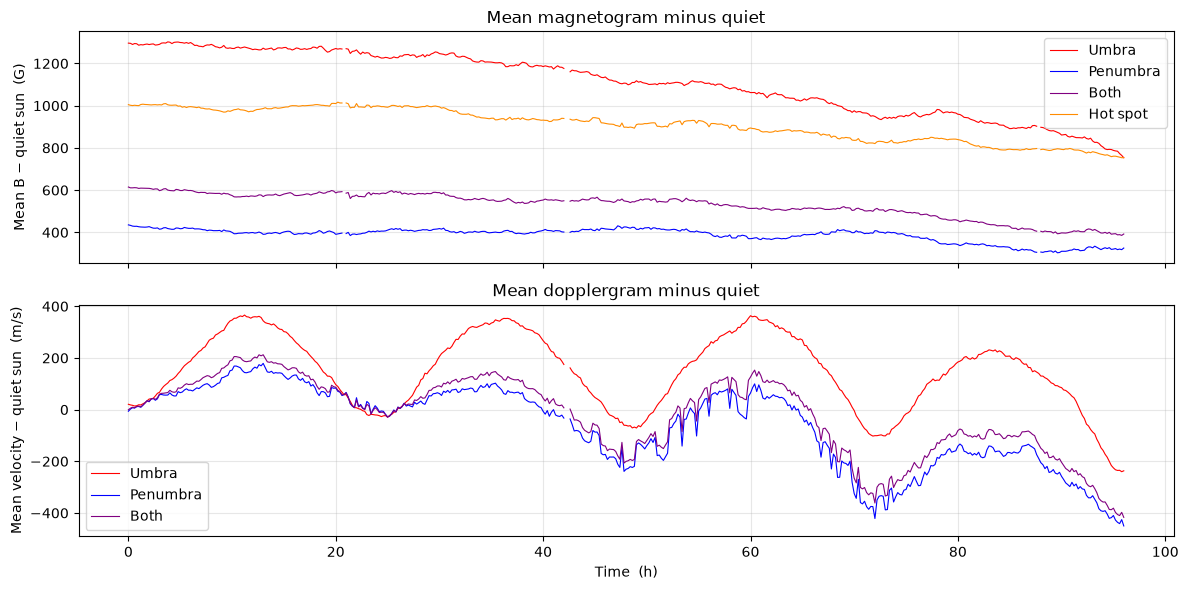

In [28]:
plot_time_series(data, metrics, subtract_quiet=True, save=False, plots_dir=plots_dir)

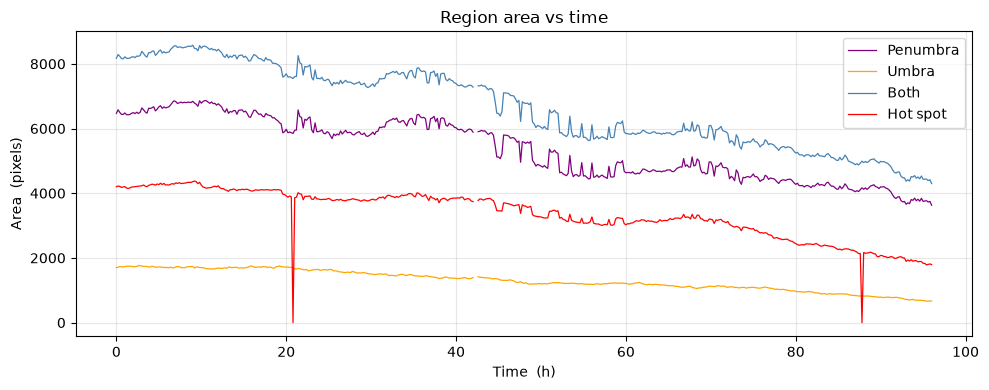

In [29]:
plot_area(data, metrics, save=False, plots_dir=plots_dir)

In [30]:
anim_path = region_dir / 'anim.html'

save_animation(
    data, metrics,
    save_path = anim_path,
    step      = max(1, data['n_t'] // 60),   # ~60 frames regardless of window length
    fps       = 5,
    mag_symmetric_cbar = True,
)

Animation size has reached 53061894 bytes, exceeding the limit of 52428800.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


Animation saved → ../data/processed/NOAA_11363_2011-12-06/anim.html  (61 frames, 52.6 MB)


In [31]:
# Open the saved animation in the browser
from IPython.display import FileLink

FileLink(str(anim_path))

/mnt/shared/Projects/sun_spots_pulsation_review/data/processed/NOAA_11363_2011-12-06/anim.html

# 11536

In [32]:
REGION_INDEX = 3

region_dir   = regions[REGION_INDEX]
plots_dir    = region_dir / 'plots'

# The masks are built right here from the corrected cubes, with REGION_KWARGS from the setup
# cell. Retune anything there and re-run from this cell down — 02A does not need to run again.
data = load_noaa_region(region_dir, **region_kwargs_for(region_dir))

print(f'{region_dir.name}')
print(f"  cube shape (n_t, ny, nx) : {data['cube_cont'].shape}")
print(f"  time span                : {data['time_h'][-1]:.1f} h "
      f"({data['n_t']} frames @ {data['cadence_s']:.0f} s)")
print(f"  segmentation (abs. DN)   : umbra < {data['umbra_thresh']:,.0f}, "
      f"penumbra < {data['penumbra_thresh']:,.0f}")

# Gap frames are NaN slots on 02A's uniform grid — a series had no frame at that time. They
# are not measurements, so anything derived from them is NaN by design.
present = data['present']
n_gaps = {k: int((~v).sum()) for k, v in present.items()}
if any(n_gaps.values()):
    print(f'  NaN (missing) frames     : {n_gaps}')
    for name, flags in present.items():
        missing = np.flatnonzero(~flags)
        for i in missing[:5]:
            print(f"      {name}: frame {i} = {data['timestamps'][i]:%Y-%m-%d %H:%M}")
        if len(missing) > 5:
            print(f'      {name}: ... and {len(missing) - 5} more')
else:
    print('  NaN (missing) frames     : none')

# How the cluster selection went. `switched` is the one to watch: if the tracker lost the
# spot and re-picked, every series has a step at that frame and nothing else would show it.
# It is not automatically a bug — a decaying spot legitimately vanishes out from under the
# tracker near the end of a long window, so check *when* it happened.
info = data['cluster_info']
if info is not None:
    with_spot = info['area'] > 0
    print(f"  cluster                  : mode={data['cluster_mode']}  "
          f"{info['n_clusters'][with_spot].min()}-{info['n_clusters'][with_spot].max()} "
          f"components/frame, keeping {100 * np.nanmean(info['fraction']):.0f}% of the dark pixels")
    switched = np.flatnonzero(info['switched'])
    if len(switched):
        print(f'  WARNING: tracker re-picked the spot in {len(switched)} frame(s), first at '
              f"{data['timestamps'][switched[0]]:%Y-%m-%d %H:%M} (frame {switched[0]})")

# Areas over the frames that have data, so a gap can't drag the mean down. `raw` is the same
# count before the cluster selection — the difference is other spots, pores and bad pixels.
with_data = present['cont']
raw = data['raw_area_px']
for name, key in [('umbra', 'umbra'), ('penumbra', 'penumbra'), ('hot_spot', None)]:
    area = data[name].sum(axis=(1, 2))[with_data]
    before = f"  (raw {raw[key][with_data].mean():.0f})" if key else ''
    print(f'  {name:9s} area px        : mean={area.mean():.0f}  min={area.min()}  '
          f'max={area.max()}{before}')


NOAA_11536_2012-07-31
  cube shape (n_t, ny, nx) : (481, 139, 484)
  time span                : 96.0 h (481 frames @ 720 s)
  segmentation (abs. DN)   : umbra < 36,213, penumbra < 54,319
  NaN (missing) frames     : {'cont': 0, 'mag': 0, 'dop': 2}
      dop: frame 169 = 2012-08-01 09:48
      dop: frame 349 = 2012-08-02 21:48
  cluster                  : mode=largest  1-8 components/frame, keeping 43% of the dark pixels
  umbra     area px        : mean=235  min=15  max=474  (raw 387)
  penumbra  area px        : mean=920  min=47  max=1915  (raw 1879)
  hot_spot  area px        : mean=611  min=54  max=1088


## Step 2 — Region visual

Check that the masks land on the spot before trusting any number derived from them.

- **Continuum** (`plot_calibration_frame`) — umbra and penumbra over the intensity image.
- **Magnetogram** (`plot_magnetogram_masks`) — purple is the whole sunspot, green is the
  hot spot. The hot spot should sit on the strong-field core, not scattered across the
  frame; if it is empty or covers everything, the `|B|` threshold in 02A needs adjusting
  for this region.

Both take `frame_idx=None` for the middle frame. Worth repeating near the start and end of
the window when the spot evolves noticeably.

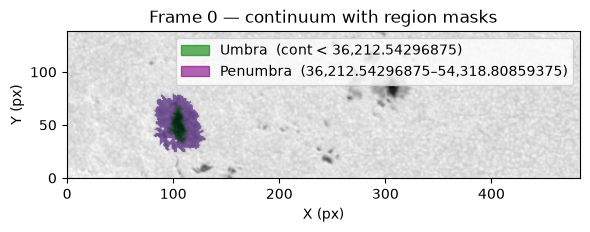

In [33]:
plot_calibration_frame(data, frame_idx=0, save=False, plots_dir=plots_dir)

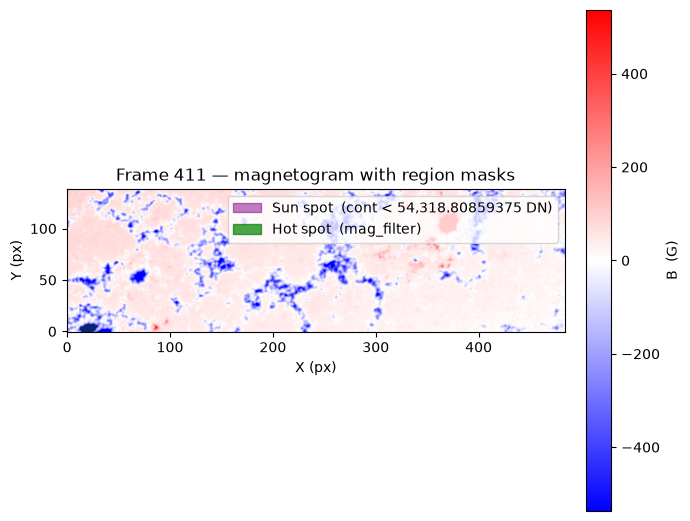

In [34]:
plot_magnetogram_masks(data, frame_idx=411, save=False, plots_dir=plots_dir)

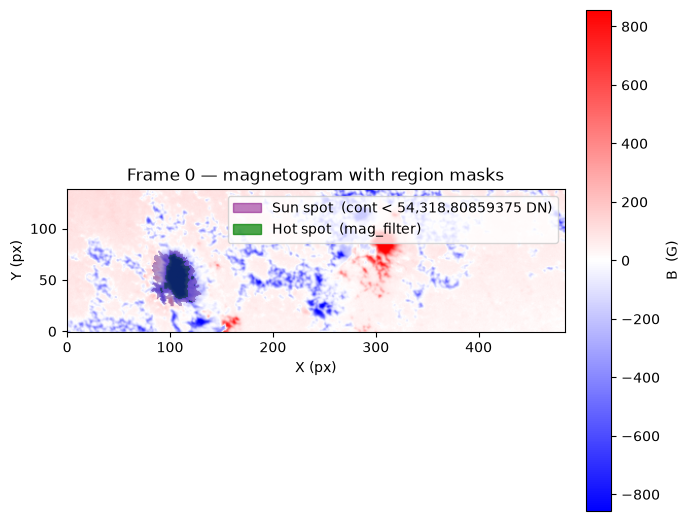

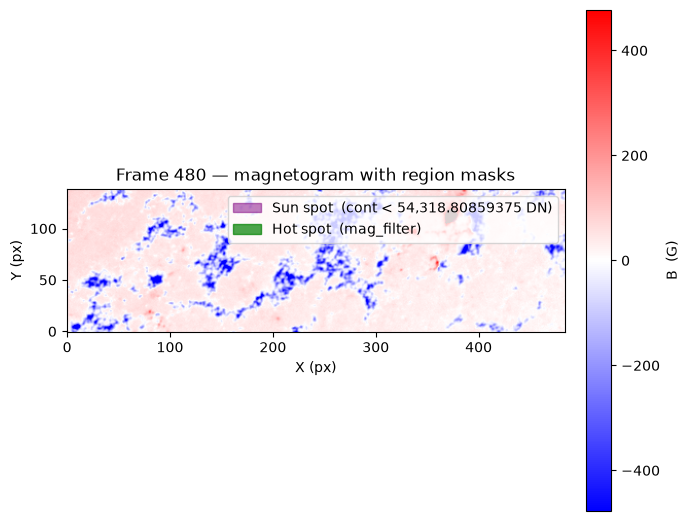

In [35]:
# First and last frame — does the mask still track the spot at the end of the window?
for idx in (0, data['n_t'] - 1):
    plot_magnetogram_masks(data, frame_idx=idx, save=False, plots_dir=plots_dir)

## Step 3 — Per-frame metrics

`compute_metrics` returns the mean magnetogram and Doppler velocity per region per frame.
Because `data['hot_spot']` is present it also returns **`mean_mag_hotspot`** and
`area_hotspot` (magnetogram only — a hot spot has no separate Doppler meaning).

**Read the two B columns together.** `compute_metrics` averages *signed* `B_los`, so a
bipolar group cancels against itself: NOAA 11536's hot spot is 27% positive and 73%
negative, which drags its signed mean (−348 G) to under half its actual `|B|` (819 G).
That matters for a pulsation search, because the signed mean can move simply because the
polarity balance moved — a change in which pixels are in the mask, not a change in field
strength. The `|B|` column is there to tell those apart.

The hot-spot mean should otherwise fall between the umbral and penumbral means: it is the
strong-field core, which spans parts of both.

In [36]:
metrics = compute_metrics(data)

print(f'{region_dir.name}\n')
print('  region        mean B (G)     |B| (G)    mean v (m/s)      area (px)')
rows = [
    ('Umbra',     'mean_mag_umb',     'mean_dop_umb',   'area_umb',     'umbra'),
    ('Penumbra',  'mean_mag_pen',     'mean_dop_pen',   'area_pen',     'penumbra'),
    ('Both',      'mean_mag_both',    'mean_dop_both',  'area_both',    'both'),
    ('Hot spot',  'mean_mag_hotspot', None,             'area_hotspot', 'hot_spot'),
    ('Quiet Sun', 'mean_mag_quiet',   'mean_dop_quiet', None,           None),
]
for label, mag_key, dop_key, area_key, mask_key in rows:
    if mag_key not in metrics:
        continue
    mag   = f'{np.nanmean(metrics[mag_key]):10.1f}'
    unsig = (f'{np.nanmean(np.abs(data["cube_mag"][data[mask_key]])):11.1f}'
             if mask_key else f'{"—":>11s}')
    dop   = f'{np.nanmean(metrics[dop_key]):12.1f}' if dop_key else f'{"—":>12s}'
    area  = f'{np.nanmean(metrics[area_key]):13.0f}' if area_key else f'{"—":>13s}'
    print(f'  {label:12s} {mag} {unsig} {dop} {area}')

# Velocities are absolute, so the physically meaningful number is the umbra relative to
# the quiet sun — suppressed convection in the umbra should leave it redshifted.
rel = np.nanmean(metrics['mean_dop_umb']) - np.nanmean(metrics['mean_dop_quiet'])
print(f'\n  umbra − quiet sun : {rel:+.1f} m/s')

# Polarity balance. compute_metrics averages *signed* B, so a bipolar group cancels
# against itself and the reported mean understates the real field — for NOAA 11536 the
# hot spot is 27% positive / 73% negative, and its signed mean (-348 G) is less than half
# its |B| (819 G). Compare the two columns above before reading anything into a trend:
# a change in the mean can be the polarity balance shifting rather than the field.
for label, mask_key in [('Umbra', 'umbra'), ('Hot spot', 'hot_spot')]:
    vals = data['cube_mag'][data[mask_key]]
    vals = vals[np.isfinite(vals)]
    if not vals.size:
        continue
    frac_pos = 100 * (vals > 0).sum() / vals.size
    print(f'  {label:10s} polarity  {frac_pos:5.1f}% positive / {100 - frac_pos:5.1f}% negative'
          + ('   <- mixed, signed mean is cancelling' if 5 < frac_pos < 95 else ''))

NOAA_11536_2012-07-31

  region        mean B (G)     |B| (G)    mean v (m/s)      area (px)
  Umbra            -821.4      1014.4          7.0           235
  Penumbra         -404.8       449.0        -77.0           920
  Both             -494.3       564.1        -64.8          1155
  Hot spot         -678.7       841.9            —           611
  Quiet Sun           0.0           —       -237.4             —

  umbra − quiet sun : +244.4 m/s
  Umbra      polarity    2.6% positive /  97.4% negative
  Hot spot   polarity    2.7% positive /  97.3% negative


/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:957: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t]) for t in range(n_qsun)]),


## Step 4 — Time series

`plot_time_series` draws mean B (top) and mean v (bottom) for umbra, penumbra, both and
quiet sun, with the **hot spot** added to the magnetogram panel in orange.

`subtract_quiet=True` re-references everything to the quiet sun, which is the right view
for the velocities given the residual HMI bias. `normalized=True` min-max scales each
series, useful for comparing the *shape* of the B and v variations rather than their size.

`plot_area` is the sanity check that belongs beside them: a mean that moves while its area
also moves is a segmentation artefact, not a measurement.

**A break in a line is a download gap, not the spot disappearing.** 02A puts the three
series on a uniform time grid and NaN-fills the slots where a series has no frame, so those
frames are missing data rather than measured zeros. `compute_metrics` sets the areas to NaN
there for the same reason — an empty mask in a gap frame would otherwise plot as a
confident drop to 0 px. `data['present']` says which slots those are.

Figure saved → ../data/processed/NOAA_11536_2012-07-31/plots/time_series.png


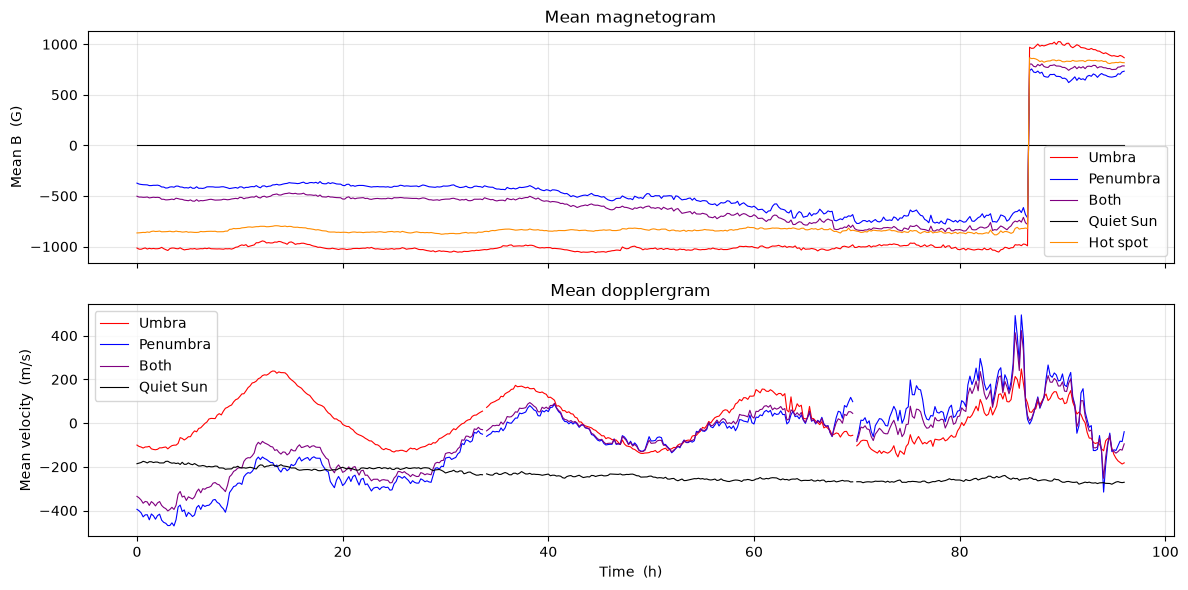

In [37]:
plot_time_series(data, metrics, save=True, plots_dir=plots_dir)

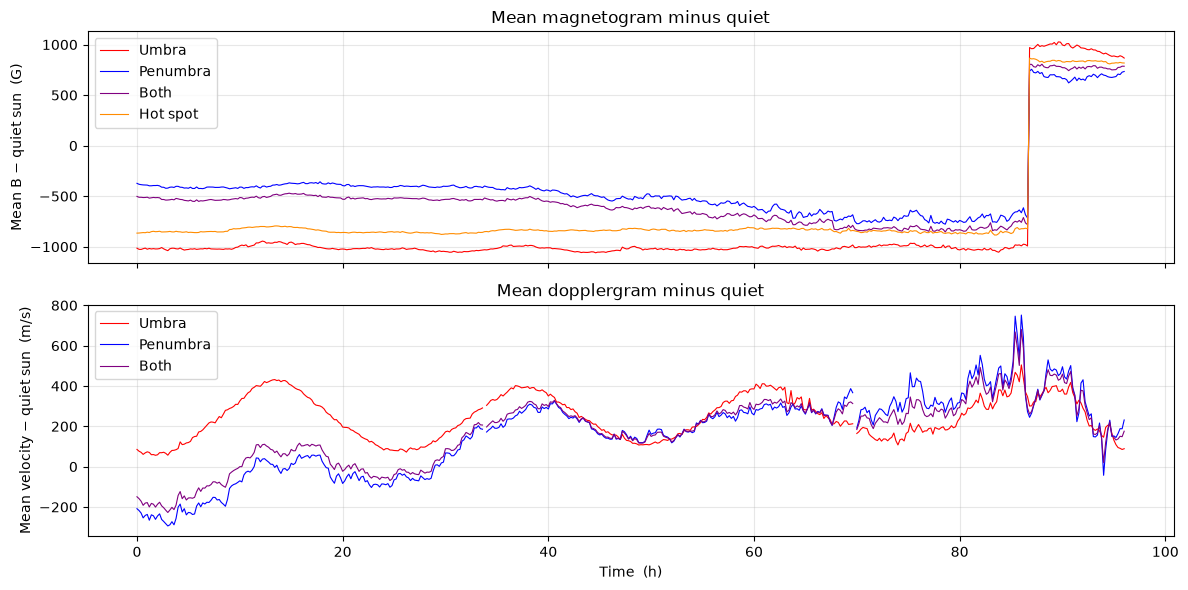

In [38]:
plot_time_series(data, metrics, subtract_quiet=True, save=False, plots_dir=plots_dir)

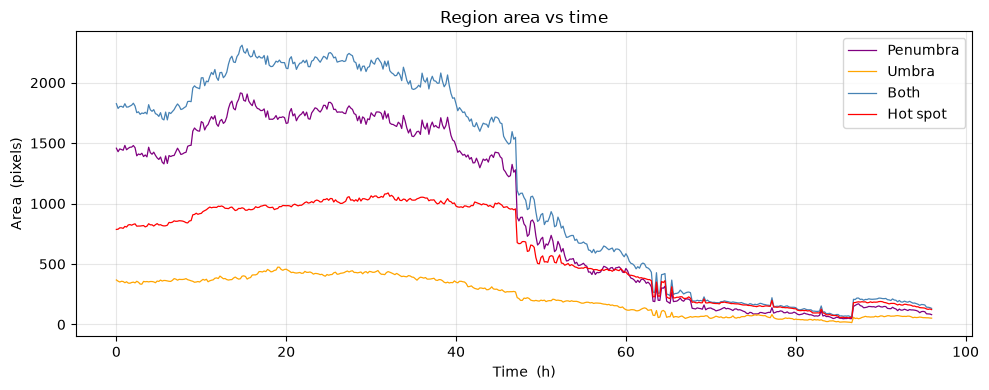

In [39]:
plot_area(data, metrics, save=False, plots_dir=plots_dir)

In [40]:
anim_path = region_dir / 'anim.html'

save_animation(
    data, metrics,
    save_path = anim_path,
    step      = max(1, data['n_t'] // 60),   # ~60 frames regardless of window length
    fps       = 5,
    mag_symmetric_cbar = True,
)

Animation saved → ../data/processed/NOAA_11536_2012-07-31/anim.html  (61 frames, 24.8 MB)


In [41]:
# Open the saved animation in the browser
from IPython.display import FileLink

FileLink(str(anim_path))

/mnt/shared/Projects/sun_spots_pulsation_review/data/processed/NOAA_11536_2012-07-31/anim.html

# All regions — comparison

One row per processed region, so the Löptien sample can be read side by side without
stepping through each one. Velocities are quoted relative to that region's own quiet sun,
since the absolute HMI bias differs between regions.

In [42]:
print(f'{"region":28s} {"n_t":>5s} {"span":>7s} {"B umb":>9s} {"B hot":>9s} '
      f'{"v umb−qs":>10s} {"area umb":>9s}')
print('-' * 84)

all_metrics = {}
for r in regions:
    d = load_noaa_region(r, **region_kwargs_for(r))
    m = compute_metrics(d)
    all_metrics[r.name] = (d, m)
    v_rel = np.nanmean(m['mean_dop_umb']) - np.nanmean(m['mean_dop_quiet'])
    b_hot = np.nanmean(m['mean_mag_hotspot']) if 'mean_mag_hotspot' in m else np.nan
    print(f"{r.name:28s} {d['n_t']:5d} {d['time_h'][-1]:6.1f}h "
          f"{np.nanmean(m['mean_mag_umb']):9.1f} {b_hot:9.1f} "
          f"{v_rel:+10.1f} {np.nanmean(m['area_umb']):9.0f}")

region                         n_t    span     B umb     B hot   v umb−qs  area umb
------------------------------------------------------------------------------------


/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:953: RuntimeWarning: Mean of empty slice
  mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t]) for t in range(n_qsun)]),
/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:957: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t]) for t in range(n_qsun)]),


NOAA_11106_2010-09-16          480   95.8h    1132.4     934.1     +215.9       218


/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:953: RuntimeWarning: Mean of empty slice
  mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t]) for t in range(n_qsun)]),
/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:957: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t]) for t in range(n_qsun)]),


NOAA_11117_2010-10-27          960   95.9h   -1121.5    -948.6      +69.0      1479


/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:953: RuntimeWarning: Mean of empty slice
  mean_mag_quiet = np.array([np.nanmean(cube_mag_qsun[t]) for t in range(n_qsun)]),
/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:957: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t]) for t in range(n_qsun)]),


NOAA_11363_2011-12-06          481   96.0h    1108.3     910.1     +145.6      1305
NOAA_11536_2012-07-31          481   96.0h    -821.4    -678.7     +244.4       235


/mnt/shared/Projects/sun_spots_pulsation_review/src/sunspot_analysis.py:957: RuntimeWarning: Mean of empty slice
  mean_dop_quiet = np.array([np.nanmean(cube_dop_qsun[t]) for t in range(n_qsun)]),


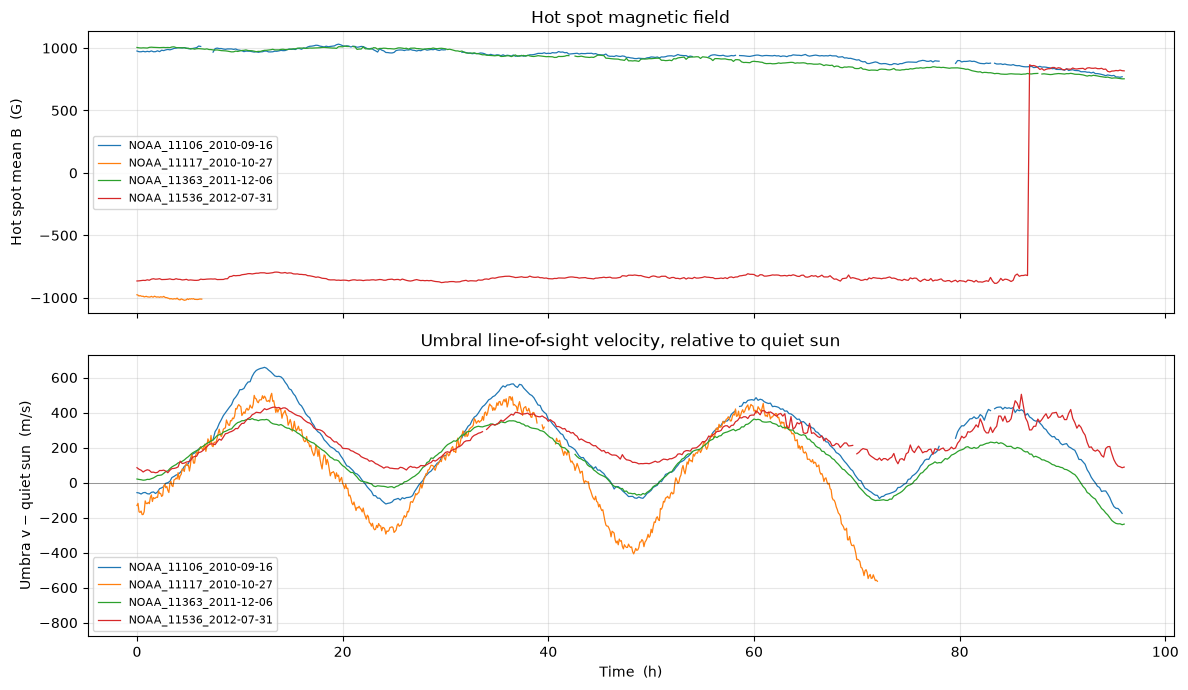

In [43]:
# Mean B in the hot spot for every region, on one axis. Each region is plotted against its
# own elapsed time, so this compares the shape of the variation, not absolute epochs.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for name, (d, m) in all_metrics.items():
    if 'mean_mag_hotspot' in m:
        ax1.plot(d['time_h'], m['mean_mag_hotspot'], lw=0.9, label=name)
    ax2.plot(d['time_h'], m['mean_dop_umb'] - m['mean_dop_quiet'], lw=0.9, label=name)

ax1.set_ylabel('Hot spot mean B  (G)')
ax1.set_title('Hot spot magnetic field')
ax1.grid(alpha=0.3)
ax1.legend(fontsize=8)

ax2.set_ylabel('Umbra v − quiet sun  (m/s)')
ax2.set_xlabel('Time  (h)')
ax2.set_title('Umbral line-of-sight velocity, relative to quiet sun')
ax2.axhline(0, color='black', lw=0.5, alpha=0.5)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Export the masks for DS9

02A writes no mask file, on purpose: the regions are rebuilt here on every run, so anything
saved beside the cubes could only go stale against the thresholds currently set above. When
you do want to overlay the regions in DS9, write them out explicitly with this cell — it
regenerates `region_01_masks_cube.fits` from whatever `REGION_KWARGS` produced, for every
region.

`uint8` bitmask, one file: bit 0 umbra, bit 1 penumbra, bit 2 hot spot. The bits overlap —
the hot spot sits inside the spot — and 0 means "not in any region", which covers both quiet
sun and the dark pixels the cluster selection discarded.

In [44]:
for name, (d, m) in all_metrics.items():
    path = write_masks_cube(
        d, PROCESSED_DIR / name / 'region_01_masks_cube.fits',
        history=[f'03A: regions rebuilt from the corrected cubes with {REGION_KWARGS}'])
    ok = d['present']['cont']
    print(f"{name:28s} -> {pathlib.Path(path).name}   "
          f"umbra {d['umbra'].sum(axis=(1, 2))[ok].mean():6.0f} px  "
          f"penumbra {d['penumbra'].sum(axis=(1, 2))[ok].mean():7.0f} px  "
          f"hot spot {d['hot_spot'].sum(axis=(1, 2))[ok].mean():6.0f} px")


NOAA_11106_2010-09-16        -> region_01_masks_cube.fits   umbra    218 px  penumbra     775 px  hot spot    546 px
NOAA_11117_2010-10-27        -> region_01_masks_cube.fits   umbra   1479 px  penumbra    5511 px  hot spot   1609 px
NOAA_11363_2011-12-06        -> region_01_masks_cube.fits   umbra   1305 px  penumbra    5352 px  hot spot   3360 px
NOAA_11536_2012-07-31        -> region_01_masks_cube.fits   umbra    235 px  penumbra     920 px  hot spot    611 px


## Step 6 — A 24 h oscillation in the umbral velocity, against the Wilson depression

The point of the whole comparison: fit a **24-hour oscillation** to each region's mean
umbral Dopplergram over a chosen stretch of its window, take the **intercept and
amplitude**, and plot that amplitude against the Wilson depression Löptien et al. report
for the same region — the table in `01A_download_data.ipynb`, measured with Hinode by a
completely different method.

### The model

```
v(t) = c + a·sin(2πt/P) + b·cos(2πt/P)          P = 24 h, held fixed
amplitude = hypot(a, b)     intercept = c
```

Holding the period fixed is what makes this reliable: the model is then **linear** in
`(c, a, b)`, so `fit_diurnal` solves it with one least-squares call that always returns the
exact optimum. Fitting `A·sin(2πt/P + φ) + c` with a non-linear optimiser describes the same
curve but needs a starting guess and can land in a local minimum.

### The windows

`t = 0` is the first frame of that region's cube — the anchor date at 00:00. That is what
lets **NOAA 11117 contribute two points from one cube**: the Löptien table lists it twice,
2010-10-27 and 2010-10-28, which are one continuous AR passage, so they become the `0–24 h`
and `24–48 h` stretches of the same series. Every window is listed explicitly in
`FIT_WINDOWS` below — edit any of them.

### Two things to read before the amplitude

- **One cycle is a weak constraint.** A 24 h period over a 24 h window completes exactly one
  cycle, and amplitude, phase and intercept are then only weakly separated — they trade
  against each other. `sigma_amplitude` is what says how badly, which is why it is in the
  table and drawn as an error bar. Widening a window past ~36 h constrains the fit far
  better; that is what the dict is for.
- **24 h is also the period of the instrument.** SDO's line-of-sight velocity is dominated
  by `OBS_VR`, which varies diurnally with its geosynchronous orbit, so any residual of the
  `v_SDO` correction sits at exactly the period being fitted. That is why both the absolute
  umbral series and the quiet-sun-subtracted one are fitted and reported side by side.
  Because the fit is linear and both use the same points, the quiet-subtracted coefficients
  are *exactly* the absolute ones minus the quiet sun's — so **the two amplitude columns
  are the control**. Close together: the oscillation is umbral. Absolute much larger: most
  of it is common to the whole box, and residual orbital velocity is the first suspect.

In [45]:
from src.sunspot_analysis import fit_diurnal, plot_diurnal_fits, plot_amplitude_vs_depression

# --- Reference data, from Löptien et al. via the table in 01A_download_data.ipynb -------
# Measured with Hinode by an independent method — this is what the fitted amplitudes get
# compared against, so it is transcribed as-is and not to be edited.
#
# 11039 and 11041 predate HMI science data (~2010-05-01), so they have no cubes and drop
# out of the loop below with a printed note rather than silently.
LOPTIEN_TABLE = [
    # noaa,  date,          theta_deg, area_Mm2, B_av,  z_div, z_press
    (11039, '2010-01-01',   29,  284, 2471, 659, 366),
    (11041, '2010-01-26',   20,  170, 2068, 638, 305),
    (11106, '2010-09-16',   27,  195, 2349, 636, 381),
    (11117, '2010-10-27',   25,  522, 2093, 561, 291),
    (11117, '2010-10-28',   35,  223, 2090, 625, 313),
    (11363, '2011-12-06',   25, 1268, 2287, 524, 326),
    (11536, '2012-07-31',   34,  124, 2181, 577, 346),
]

# --- The knob ---------------------------------------------------------------------------
# (noaa, date) -> (t_start, t_end) in hours from the FIRST FRAME of that region's cube,
# which is the anchor date at 00:00. Edit freely.
#
# 11117 appears twice because the Löptien table does: 2010-10-27 and 2010-10-28 are one
# continuous AR passage in a single cube, so its two rows are the 0-24 h and 24-48 h
# stretches of the same series and give two independent data points.
#
# Every row is written out rather than derived from the date offset, because these are
# meant to be changed. A window longer than ~36 h constrains the fit considerably better
# than one period does — see the caveat above.
FIT_PERIOD_H = 24.0
FIT_WINDOWS = {
    (11106, '2010-09-16'): (0, 24),
    (11117, '2010-10-27'): (0, 24),
    (11117, '2010-10-28'): (24, 48),
    (11363, '2011-12-06'): (0, 24),
    (11536, '2012-07-31'): (0, 24),
}

print(f'{len(FIT_WINDOWS)} window(s) configured, period {FIT_PERIOD_H:g} h:')
for (noaa, date), (t0, t1) in FIT_WINDOWS.items():
    span = t1 - t0
    flag = '' if span >= 1.5 * FIT_PERIOD_H else f'   <- {span / FIT_PERIOD_H:.2f} periods only'
    print(f'  NOAA {noaa} {date}   {t0:5.1f} .. {t1:5.1f} h   ({span:.0f} h){flag}')

5 window(s) configured, period 24 h:
  NOAA 11106 2010-09-16     0.0 ..  24.0 h   (24 h)   <- 1.00 periods only
  NOAA 11117 2010-10-27     0.0 ..  24.0 h   (24 h)   <- 1.00 periods only
  NOAA 11117 2010-10-28    24.0 ..  48.0 h   (24 h)   <- 1.00 periods only
  NOAA 11363 2011-12-06     0.0 ..  24.0 h   (24 h)   <- 1.00 periods only
  NOAA 11536 2012-07-31     0.0 ..  24.0 h   (24 h)   <- 1.00 periods only


In [46]:
import pandas as pd

# One fitted row per Löptien table entry that has data. `all_metrics` was built by the
# "All regions" cell above, so nothing is loaded from disk twice.
by_noaa = {}
for name, (d, m) in all_metrics.items():
    noaa = int(name.split('_')[1])
    by_noaa[noaa] = (name, d, m)

fit_rows, skipped = [], []
for noaa, date, theta, area_mm2, b_av, z_div, z_press in LOPTIEN_TABLE:
    window = FIT_WINDOWS.get((noaa, date))
    if noaa not in by_noaa:
        skipped.append(f'NOAA {noaa} {date}: no processed cube')
        continue
    if window is None:
        skipped.append(f'NOAA {noaa} {date}: no entry in FIT_WINDOWS')
        continue

    region_name, d, m = by_noaa[noaa]
    time_h   = d['time_h']
    v_abs    = m['mean_dop_umb']
    v_rel    = m['mean_dop_umb'] - m['mean_dop_quiet']
    label    = f'NOAA {noaa} {date}'

    # One shared mask for both fits. This is what makes the two amplitude columns a real
    # control rather than two loosely related numbers: over identical points the linear fit
    # of (umbra - quiet) is exactly the fit of umbra minus the fit of quiet.
    shared = np.isfinite(v_abs) & np.isfinite(v_rel)

    fit_abs = fit_diurnal(time_h, v_abs, window=window, period_h=FIT_PERIOD_H,
                          mask=shared, label=f'{label} abs')
    fit_rel = fit_diurnal(time_h, v_rel, window=window, period_h=FIT_PERIOD_H,
                          mask=shared, label=f'{label} rel')

    fit_rows.append(dict(
        label=label, noaa=noaa, date=date, region=region_name, window=window,
        theta_deg=theta, area_mm2=area_mm2, b_av=b_av, z_div=z_div, z_press=z_press,
        time_h=time_h, series=v_abs, series_rel=v_rel,
        fit_abs=fit_abs, fit_rel=fit_rel,
    ))

for note in skipped:
    print(f'  skipped  {note}')
print()

header = (f'{"region":22s} {"window (h)":>12s} {"n":>4s} | '
          f'{"intercept":>10s} {"amplitude":>16s} {"t_max":>7s} {"rms":>7s} | '
          f'{"intercept":>10s} {"amplitude":>16s}')
print(f'{"":22s} {"":>12s} {"":>4s} | {"--- umbra, absolute (m/s) ---":^43s} | '
      f'{"--- umbra - quiet sun (m/s) ---":^29s}')
print(header)
print('-' * len(header))
for row in fit_rows:
    a, r = row['fit_abs'], row['fit_rel']
    t0, t1 = row['window']
    print(f'{row["label"]:22s} {f"{t0:.0f}-{t1:.0f}":>12s} {a["n"]:4d} | '
          f'{a["intercept"]:10.1f} {a["amplitude"]:8.1f} ± {a["sigma_amplitude"]:5.1f} '
          f'{a["t_max"]:7.1f} {a["rms_residual"]:7.1f} | '
          f'{r["intercept"]:10.1f} {r["amplitude"]:8.1f} ± {r["sigma_amplitude"]:5.1f}')

# How much of the absolute amplitude survives the quiet-sun subtraction. Near 1 means the
# oscillation is umbral; well below 1 means most of it moved the whole box together, which
# at a 24 h period points at residual SDO orbital velocity rather than at the sunspot.
print()
for row in fit_rows:
    a, r = row['fit_abs']['amplitude'], row['fit_rel']['amplitude']
    if np.isfinite(a) and a > 0:
        print(f'  {row["label"]:22s} umbral fraction of the amplitude: {r / a:.2f}'
              + ('   <- mostly common to the whole box' if r / a < 0.5 else ''))

# Saved next to the cubes, one row per table entry, so the numbers can be re-read without
# re-running the notebook.
fit_csv = PROCESSED_DIR / 'diurnal_fits.csv'
pd.DataFrame([{
    'label': row['label'], 'noaa': row['noaa'], 'date': row['date'],
    'region': row['region'], 'period_h': FIT_PERIOD_H,
    'window_start_h': row['window'][0], 'window_end_h': row['window'][1],
    'n_points': row['fit_abs']['n'],
    'theta_deg': row['theta_deg'], 'area_mm2': row['area_mm2'], 'b_av_G': row['b_av'],
    'z_div_km': row['z_div'], 'z_press_km': row['z_press'],
    **{f'{k}_abs': row['fit_abs'][k] for k in
       ('intercept', 'amplitude', 'sigma_intercept', 'sigma_amplitude', 't_max', 'rms_residual')},
    **{f'{k}_rel': row['fit_rel'][k] for k in
       ('intercept', 'amplitude', 'sigma_intercept', 'sigma_amplitude', 't_max', 'rms_residual')},
} for row in fit_rows]).to_csv(fit_csv, index=False, float_format='%.4f')
print(f'\nFits saved → {fit_csv}  ({len(fit_rows)} rows)')

  skipped  NOAA 11039 2010-01-01: no processed cube
  skipped  NOAA 11041 2010-01-26: no processed cube

                                         |        --- umbra, absolute (m/s) ---        | --- umbra - quiet sun (m/s) ---
region                   window (h)    n |  intercept        amplitude   t_max     rms |  intercept        amplitude
--------------------------------------------------------------------------------------------------------------------
NOAA 11106 2010-09-16          0-24  116 |       14.7    343.5 ±   4.0    12.5    30.7 |      255.6    339.9 ±   3.7
NOAA 11117 2010-10-27          0-24  241 |     -175.5    302.3 ±   3.5    11.7    38.1 |      142.0    312.8 ±   3.5
NOAA 11117 2010-10-28         24-48  230 |     -203.7    356.0 ±   4.7    35.8    51.1 |      111.8    363.1 ±   4.7
NOAA 11363 2011-12-06          0-24  121 |      -93.2    180.1 ±   2.2    11.6    17.3 |      183.1    178.7 ±   1.3
NOAA 11536 2012-07-31          0-24  121 |       35.6    165.0 ±   2.1  

/tmp/ipykernel_76722/2907804226.py:31: UserWarning: fit_diurnal [NOAA 11106 2010-09-16 abs]: the 24 h window is only 1.00 periods long. Amplitude, phase and intercept are poorly separated over so little of a cycle — read sigma_amplitude before reading amplitude.
  fit_abs = fit_diurnal(time_h, v_abs, window=window, period_h=FIT_PERIOD_H,
/tmp/ipykernel_76722/2907804226.py:33: UserWarning: fit_diurnal [NOAA 11106 2010-09-16 rel]: the 24 h window is only 1.00 periods long. Amplitude, phase and intercept are poorly separated over so little of a cycle — read sigma_amplitude before reading amplitude.
  fit_rel = fit_diurnal(time_h, v_rel, window=window, period_h=FIT_PERIOD_H,
/tmp/ipykernel_76722/2907804226.py:31: UserWarning: fit_diurnal [NOAA 11117 2010-10-27 abs]: the 24 h window is only 1.00 periods long. Amplitude, phase and intercept are poorly separated over so little of a cycle — read sigma_amplitude before reading amplitude.
  fit_abs = fit_diurnal(time_h, v_abs, window=window, per


Fits saved → ../data/processed/diurnal_fits.csv  (5 rows)


### Look at the fits before reading the scatter

A fit that latched onto a download gap, a segmentation step or a slow trend still produces a
perfectly respectable number. The only way to catch that is to look at the curve sitting on
the points: the shaded band is the fitted window, the grey line is the rest of the series for
context, and the dotted line is the intercept.

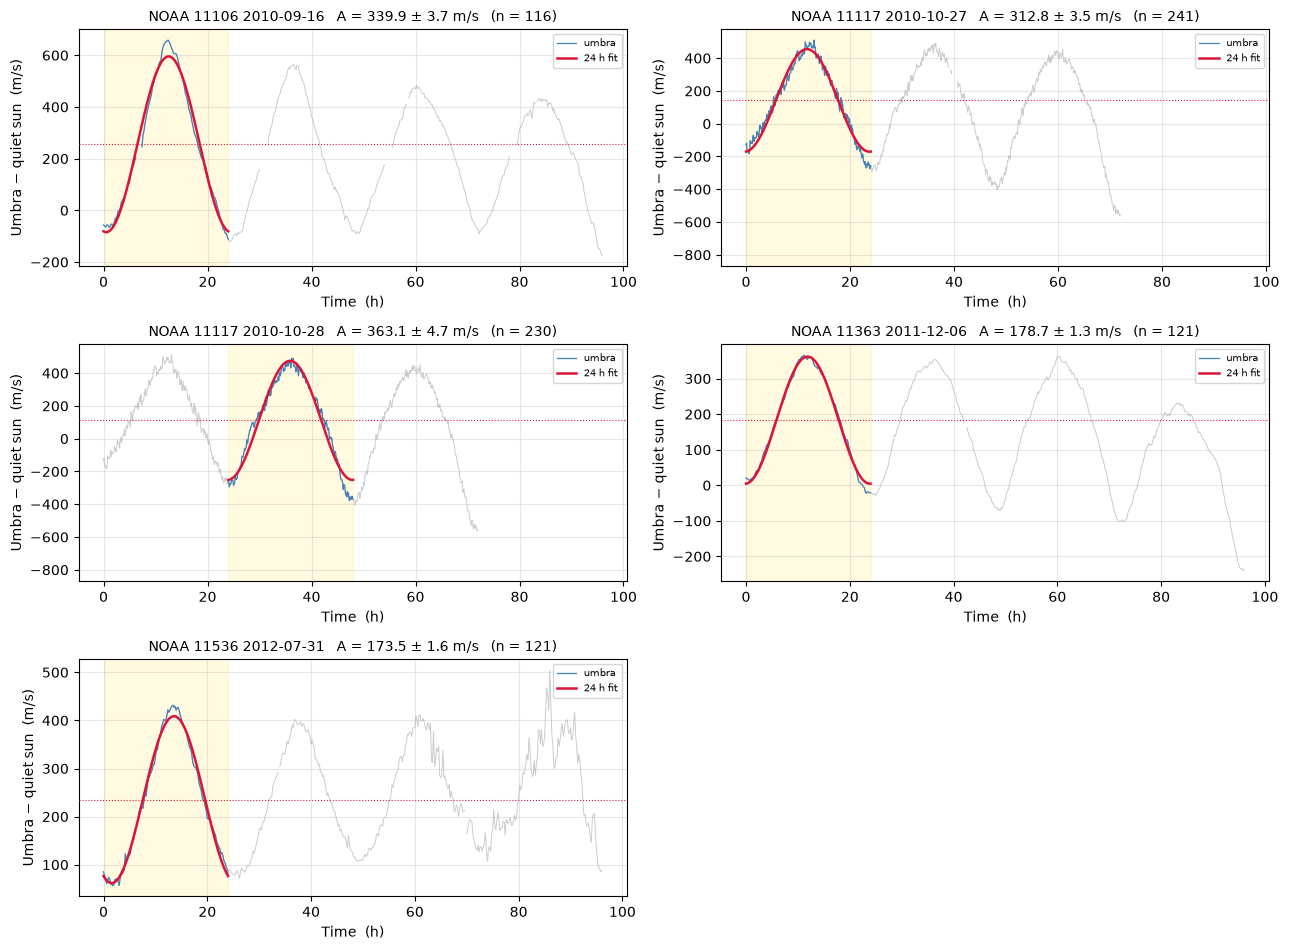

In [47]:
plot_diurnal_fits(fit_rows, series_key='fit_rel', save=False,
                  plots_dir=PROCESSED_DIR / 'plots')

### Amplitude vs Wilson depression

The comparison itself: the fitted 24 h amplitude against `z_W,div`, one point per Löptien
table row, with 11117 appearing twice from its two windows. Error bars are the fit's own
`sigma_amplitude`.

Both series are drawn — orange for the absolute umbral velocity, blue for the same thing with
the quiet sun removed. **Markers sitting on top of each other means the oscillation is
umbral; a much higher orange point means most of that amplitude moved the whole box
together**, and at a 24 h period residual SDO orbital velocity is the first thing to suspect.

The annotated Pearson *r* is a description of these five (or six) points, not evidence of a
relationship — with this many points a single region moves it substantially. Pass
`depth_key='z_press'` to swap the x axis to the pressure-based depression, which disagrees
with `z_W,div` by up to a factor of two in the table.

In [48]:
fit_rows[0].keys()

dict_keys(['label', 'noaa', 'date', 'region', 'window', 'theta_deg', 'area_mm2', 'b_av', 'z_div', 'z_press', 'time_h', 'series', 'series_rel', 'fit_abs', 'fit_rel'])

In [57]:

def plot_amplitude_vs_depression(
    rows: list[dict],
    depth_key: str = 'z_div',
    save: bool = False,
    plots_dir: str | pathlib.Path | None = None,
    normalize_area = False
) -> None:
    """Fitted 24 h amplitude against the Wilson depression reported for each region.

    Both fitted series are drawn: the absolute umbral velocity and the same thing with the
    quiet sun subtracted. That pair is the instrumental control — see `fit_diurnal`'s
    notes. If the two markers for a region sit on top of each other the oscillation is
    umbral; if the absolute one is far higher, most of that amplitude is common to the
    whole box and is more likely a residual of the diurnal ``v_SDO`` correction than a
    property of the sunspot.

    Pearson r is annotated per series, with the number of points it was computed from.
    With five points it is a description of this sample, not evidence of a relationship.
    """
    usable = [r for r in rows if np.isfinite(r['fit_rel']['amplitude'])
              and np.isfinite(r[depth_key])]
    if len(usable) < 2:
        print(f'plot_amplitude_vs_depression: only {len(usable)} usable point(s)')
        return

    depth_label = {'z_div': r'$z_{W,\mathrm{div}}$', 'z_press': r'$z_{W,\mathrm{press}}$'}
    fig, ax = plt.subplots(figsize=(8, 6))

    for key, color, marker, name in [
            ('fit_abs', 'darkorange', 'o', 'Umbra, absolute'),
            ('fit_rel', 'steelblue', 's', 'Umbra − quiet sun')]:
        y = np.array([r[depth_key] for r in usable], dtype=float)

        if normalize_area:
            x = np.array([r[key]['amplitude'] / r['area_mm2'] for r in usable], dtype=float)
            e = np.array([r[key]['sigma_amplitude'] / r['area_mm2'] for r in usable], dtype=float)

        else:
            x = np.array([r[key]['amplitude'] for r in usable], dtype=float)
            e = np.array([r[key]['sigma_amplitude'] for r in usable], dtype=float)
        ax.errorbar(x, y, yerr=e, fmt=marker, color=color, ms=7, capsize=3, lw=0,
                    elinewidth=1, label=name)

        finite = np.isfinite(x) & np.isfinite(y)
        if finite.sum() > 2:
            r_p = float(np.corrcoef(x[finite], y[finite])[0, 1])
            ax.plot([], [], ' ', label=f'   r = {r_p:+.2f}  (n = {int(finite.sum())})')

    # Label each point once, next to the quiet-subtracted marker.
    for row in usable:
        ax.annotate(row['label'], (row[depth_key], row['fit_rel']['amplitude']),
                    textcoords='offset points', xytext=(7, 4), fontsize=7, color='0.3')

    period = usable[0]['fit_rel']['period_h']
    ax.set_ylabel(f'Wilson depression {depth_label.get(depth_key, depth_key)}  (km)')
    ax.set_xlabel(f'Fitted {period:g} h amplitude (m/s)' + (' / area' if normalize_area else ''))
    ax.set_title(f'{period:g} h umbral Doppler amplitude vs Wilson depression')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    #savefig(fig, plots_dir if save else None, f'amplitude_vs_{depth_key}.png')
    plt.show()
    plt.close(fig)


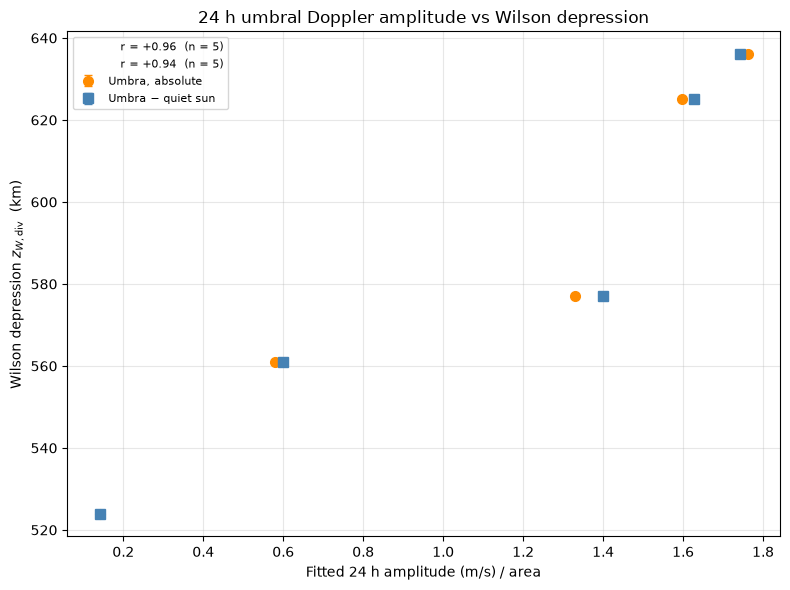

In [58]:
plot_amplitude_vs_depression(fit_rows, depth_key='z_div', save=False,
                             plots_dir=PROCESSED_DIR / 'plots',normalize_area=True)

### What the fits actually say — read this before quoting an amplitude

Measured on the four processed regions, umbra − quiet sun, widening the window from one
cycle to four:

| region | window | n | amplitude | σ | resid. rms | `t_max` mod 24 h |
| --- | --- | --- | --- | --- | --- | --- |
| 11106 | 0–24 | 116 | 328.3 | 3.7 | 28.6 | **12.5** |
| 11106 | 0–48 | 229 | 306.6 | 3.3 | 35.7 | **12.5** |
| 11106 | 0–96 | 452 | 273.4 | 3.1 | 47.3 | **12.5** |
| 11117 | 0–24 | 241 | 275.5 | 2.9 | 32.1 | **11.7** |
| 11117 | 0–96 | 829 | 329.0 | 5.2 | 105.4 | **11.7** |
| 11363 | 0–24 | 121 | 164.0 | 1.1 | 8.7 | **12.0** |
| 11363 | 0–96 | 479 | 177.2 | 3.7 | 57.2 | **11.9** |
| 11536 | 0–24 | 121 | 187.7 | 1.7 | 12.9 | **13.6** |
| 11536 | 0–96 | 479 | 160.2 | 1.9 | 30.0 | **13.8** |

Two things follow, and the second one matters more than the amplitudes.

**The signal is real and stable.** The amplitude holds to within ~20% as the window goes from
one cycle to four, and the residual RMS stays well below it. So this is not a monotonic trend
being absorbed by a single cycle of a sine — that failure mode would have collapsed the
amplitude once a second cycle was added.

**But its phase is locked to the clock, not to the spot.** `t_max` sits at **11.7–13.8 h
after 00:00 TAI in all four regions**, and stays there when the window widens. Those regions
are from September 2010, October 2010, December 2011 and July 2012 — different spots,
different sizes, different disk positions, three different years. An oscillation intrinsic to
a sunspot has no reason to share a phase across all of that. A signal tied to the observatory's
own daily cycle does.

Note also that it **survives the quiet-sun subtraction almost untouched** (umbral fraction
0.99–1.05 in the table above). That rules out a *spatially uniform* residual — the `v_SDO`
correction is nearly constant across the box, so any leftover of it cancels in
umbra − quiet sun. What is left is a *differential* effect between the umbra and the quiet
sun, which is what HMI's known line-profile dependence produces: the Fe I 6173.3 Å line is
cool, deep and Zeeman-split in the umbra and not in the quiet sun, so the same orbital-velocity
systematic converts into a different velocity error in each.

So: treat the amplitude in the scatter plot as a **measurement of a 24 h systematic whose size
varies from spot to spot**, and any correlation with the Wilson depression as a statement
about *that* — which is itself worth knowing, since a depression-dependent line-profile
systematic is exactly what would mimic a depression-dependent oscillation. Establishing that
the signal is intrinsically solar needs something this notebook does not yet do: a phase that
tracks the spot rather than TAI, or the same measurement from an instrument on a different
orbit.